# Bilevel Coresets trên KMNIST (Kuzushiji-MNIST)

Notebook này chạy **trọn vẹn từ A đến Z** bộ thực nghiệm của bài báo
*Data Summarization via Bilevel Optimization* (Borsos, Mutný, Tagliasacchi, Krause —
JMLR 25 (2024) 1–53, [arXiv:2109.12534](https://arxiv.org/abs/2109.12534))
trên một bộ dữ liệu **mới**: **KMNIST**.

## Vì sao chọn KMNIST?

| | FashionMNIST (đã chạy) | **KMNIST (notebook này)** | SMNIST (bài báo) |
|---|---|---|---|
| Ảnh | 28×28, xám | 28×28, xám | 28×28, xám |
| Lớp | 10 | 10 | 10 |
| Train / Test | 60.000 / 10.000 | 60.000 / 10.000 | 60.000 / 10.000 |
| Nội dung | quần áo | chữ Hán–Nhật cổ (Kuzushiji) | chữ số viết tay |
| Độ khó (CNN) | ~91% | ~95% | ~99% |

KMNIST là bộ **thay thế trực tiếp**: kiến trúc `models.ConvNet` (`Conv2d(1, 32, 5)`)
và Convolutional NTK (`reshape(-1, 28, 28, 1)`) trong repo **không cần sửa một dòng nào**.
Chỉ cần đăng ký thêm tên dataset — notebook tự làm việc đó ở Bước 1.

Điểm quan trọng về mặt khoa học: trên MNIST mọi phương pháp đều bão hòa ~99% nên
khác biệt giữa các baseline chìm trong nhiễu. KMNIST khó hơn MNIST đủ để **còn khoảng
trống cho coreset thể hiện**, nhưng vẫn nhẹ như MNIST về chi phí tính toán.

## Notebook này chạy những gì

| Mục | Tương ứng bài báo | Kết quả |
|---|---|---|
| 2. Kiểm chứng dữ liệu | §5 (tiền xử lý) | ảnh mẫu + kiểm chứng hằng số chuẩn hóa |
| 3. Continual Learning | **Table 3** (§5.3) | 16 phương pháp, 3 biểu đồ |
| 4. Ablation | Appendix D, Table 9 | quét buffer size & β |
| 5. Nhiều seed | — | error bar cho Uniform vs BiCo |
| 6. Streaming | **Table 5 + Table 6** (§5.4) | cân bằng & mất cân bằng |
| 7. Biến thể Algorithm 1 | **Figure 3** (§5.1) | quét kích thước coreset |
| 8. So sánh với FashionMNIST | — | biểu đồ đối chiếu 2 bộ dữ liệu |

## Hướng dẫn chạy

1. Bật **GPU** (T4 hoặc P100) trong *Settings* của Kaggle.
2. Chạy Ô 1 (clone) → Ô 2 (cài thư viện) → **Restart Session** khi Kaggle yêu cầu.
3. Chạy lần lượt các ô còn lại từ trên xuống. Ô cấu hình sẽ tự `cd` lại vào repo
   sau khi restart, nên không cần chạy lại Ô 1.

**Thời gian dự kiến trên T4: khoảng 3–3,5 giờ.** Mỗi ô nặng đều in thời gian chạy
từng bước; nếu một phương pháp lỗi, notebook **ghi nhận và chạy tiếp** chứ không dừng.

---
## Ô 1 — Tải mã nguồn

In [1]:
!git clone https://github.com/quachthanhhmd/bilevel-coresets.git
%cd bilevel-coresets
!git checkout bugfix/fixing-jax-error

Cloning into 'bilevel-coresets'...
remote: Enumerating objects: 345, done.
remote: Counting objects: 100% (345/345), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 345 (delta 172), reused 322 (delta 149), pack-reused 0 (from 0)
Receiving objects: 100% (345/345), 674.63 KiB | 4.47 MiB/s, done.
Resolving deltas: 100% (172/172), done.
/kaggle/working/bilevel-coresets
Branch 'bugfix/fixing-jax-error' set up to track remote branch 'bugfix/fixing-jax-error' from 'origin'.
Switched to a new branch 'bugfix/fixing-jax-error'


## Ô 2 — Cài môi trường

- `setuptools<70` để vá lỗi build của Python 3.12 trên Kaggle.
- `neural-tangents` để tính Neural Tangent Kernel — chỉ cần cho `--method coreset`
  (proxy NTK, §3.5.2 của bài báo).

Repo đã có sẵn `jax_patch.py` (vá các API JAX cũ mà `neural-tangents` cần) và
`cl.py` / `streaming.py` **tự import nó**, nên không cần vá tay trong notebook.

> ⚠️ **Bấm `Restart Session` sau khi ô này chạy xong**, rồi chạy tiếp từ Ô 3.

In [2]:
!pip install -q "setuptools<70.0.0"
!pip install -q neural-tangents

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.7/248.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 6.1 MB/s eta 0:00:00


---
## Ô 3 — Cấu hình

Toàn bộ tham số của notebook nằm ở đây. Muốn chạy nhanh hơn thì giảm
`VARIANT_SIZES` hoặc bỏ bớt phần tử trong `CL_METHODS`.

In [3]:
import os, sys, json, time, shutil, subprocess
import numpy as np

# --- tự động quay lại thư mục repo sau khi Restart Session ---
REPO = '/kaggle/working/bilevel-coresets'
if not os.path.isdir(REPO):                       # chạy ngoài Kaggle
    REPO = os.path.abspath('bilevel-coresets' if os.path.isdir('bilevel-coresets') else '.')
os.chdir(REPO)
print('repo:', os.getcwd())

CL_DIR   = os.path.join(REPO, 'cl_streaming')
EXP_DIR  = os.path.join(REPO, 'experiments')
FIG_DIR  = os.path.join(REPO, 'kmnist_figures')       # nơi gom mọi hình
ALGO1_DIR = os.path.join(EXP_DIR, 'algo1_kmnist_results')
os.makedirs(FIG_DIR, exist_ok=True)

# cl.py / streaming.py chỉ import đúng khi chạy với cwd=cl_streaming/ VÀ repo root
# nằm trong PYTHONPATH -- đúng như run_experiments.sh làm.
ENV = os.environ.copy()
ENV['PYTHONPATH'] = REPO + os.pathsep + ENV.get('PYTHONPATH', '')

DATASET      = 'splitkmnist'
DATASET_IMB  = 'splitkmnistimbalanced'
BUFFER_SIZE  = 100
BETA         = 1.0
SEED         = 0

# 15 phương pháp của Table 3 (13 gốc + forgetting + 2 baseline riêng của repo)
CL_METHODS = [
    'uniform', 'coreset',
    'kmeans_features', 'kcenter_features',
    'kmeans_embedding', 'kcenter_embedding',
    'kmeans_grads', 'kcenter_grads',
    'grad_matching', 'entropy', 'hardest',
    'frcl', 'icarl', 'forgetting',
    'sensitivity', 'glister',
]

# Mục 5: chạy thêm seed để có error bar cho cặp so sánh quan trọng nhất
MULTI_SEED_METHODS = ['uniform', 'coreset']
EXTRA_SEEDS        = [1, 2]

# Mục 7: quét kích thước coreset (Figure 3). Dừng ở 200 vì bico_fwd tăng
# chi phí xây dựng theo m^2 -- ở m=800 trên FashionMNIST mất 2292 giây/điểm.
VARIANT_SIZES   = [50, 100, 200]
VARIANT_METHODS = ['uniform', 'bico_fwd', 'bico_fwd_b', 'bico_elim', 'bico_exch', 'bico_reg']

# Mục 12b (TUỲ CHỌN): pipeline "đúng chuẩn bài báo" Sec. 5.1 (proxy CNTK-Nyström).
# Rất tốn thời gian -- đặt True và đọc kỹ phần mô tả ở Ô 12b trước khi chạy.
RUN_PAPER_S51 = False

FAILURES = []

def run(cmd, cwd=None, label=None):
    '''Chạy một lệnh con, in thời gian, KHÔNG dừng notebook nếu lỗi.'''
    label = label or ' '.join(cmd)
    t0 = time.time()
    p = subprocess.run(cmd, cwd=cwd, env=ENV, capture_output=True, text=True)
    dt = time.time() - t0
    if p.returncode != 0:
        print('[LOI  {:7.1f}s] {}'.format(dt, label))
        print('    ' + (p.stderr.strip().splitlines() or ['(khong co stderr)'])[-1][:400])
        FAILURES.append(label)
        return False
    tail = [l for l in p.stdout.strip().splitlines() if l.strip()]
    print('[ok   {:7.1f}s] {}{}'.format(dt, label, '  |  ' + tail[-1][:90] if tail else ''))
    return True

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

from IPython.display import Image, display
def show(path, width=900):
    if os.path.exists(path):
        display(Image(filename=path, width=width))
    else:
        print('(chua co hinh: {})'.format(path))

print('cau hinh xong.')

repo: /kaggle/working/bilevel-coresets
cau hinh xong.


---
## Ô 4 — Thêm hỗ trợ KMNIST vào repo

Repo gốc chỉ biết `permmnist / splitmnist / splitfashionmnist`. Ô này vá 4 file
(**chạy lại nhiều lần vẫn an toàn** — có kiểm tra trùng lặp):

| File | Sửa gì |
|---|---|
| `cl_streaming/datagen.py` | thêm `kmnist_transforms()` + 2 lớp `SplitKMnistGenerator`, `SplitKMnistImbalancedGenerator` |
| `cl_streaming/cl.py` | đăng ký `splitkmnist` |
| `cl_streaming/streaming.py` | đăng ký `splitkmnist`, `splitkmnistimbalanced` |
| `experiments/run_algorithm1_variants_fashion.py` | thêm cờ `--dataset {fashion,kmnist}` |
| `experiments/algorithm1_variants_fashion_plot.py` | thêm cờ `--title` |
| `experiments/run_algorithm1_variants_paper_cifar10.py` | thêm `kmnist` vào pipeline CNTK-Nyström (Ô 12b) |
| `experiments/algorithm1_variants_paper_cifar10_plot.py` | thêm nhãn `KMNIST` |

Hai lớp generator được **sinh tự động từ chính mã nguồn của bản FashionMNIST**
(đọc source, thay tên lớp/dataset/transform) — nhờ vậy logic chia 5 task
(`sets_0=[0,2,4,6,8]`, `sets_1=[1,3,5,7,9]`) và logic mất cân bằng
(4 task đầu 200 điểm, task cuối 2000 điểm) giữ **y hệt** bản FashionMNIST,
không có nguy cơ chép sai.

**Hằng số chuẩn hóa KMNIST `(0.1918, 0.3483)`** được tính từ toàn bộ 60.000 ảnh
train — Ô 6 sẽ kiểm chứng lại con số này.

In [4]:
def patch_file(path, anchor, addition, marker, where='after'):
    """Chen `addition` truoc/sau `anchor`, hoac thay the `anchor` (where='replace').

    Bo qua neu `marker` da co trong file -> chay lai o nay nhieu lan van an toan.
    """
    with open(path) as f:
        src = f.read()
    if marker in src:
        print('  = da co, bo qua : {}'.format(os.path.relpath(path, REPO)))
        return False
    if anchor not in src:
        raise RuntimeError('khong tim thay moc trong {}:\n{}'.format(path, anchor))
    new = {'after': anchor + addition,
           'before': addition + anchor,
           'replace': addition}[where]
    src = src.replace(anchor, new, 1)
    with open(path, 'w') as f:
        f.write(src)
    print('  + da va        : {}'.format(os.path.relpath(path, REPO)))
    return True


# ---------------------------------------------------------------- datagen.py
datagen_path = os.path.join(CL_DIR, 'datagen.py')
with open(datagen_path) as f:
    datagen_src = f.read()

if 'class SplitKMnistGenerator' in datagen_src:
    print('  = da co, bo qua : cl_streaming/datagen.py')
else:
    # Sinh phien ban KMNIST tu chinh source cua 2 lop FashionMNIST
    def grab(start_marker, end_marker):
        i = datagen_src.index(start_marker)
        j = datagen_src.index(end_marker)
        assert j > i, 'thu tu lop trong datagen.py khac du kien'
        return datagen_src[i:j]

    block = (grab('class SplitFashionMnistGenerator', 'class SplitMnistGenerator')
             + grab('class SplitFashionMnistImbalancedGenerator', 'class SplitMnistImbalancedGenerator'))
    block = (block.replace('FashionMnist', 'KMnist')
                  .replace('FashionMNIST', 'KMNIST')
                  .replace('fashion_mnist_transforms', 'kmnist_transforms'))

    header = (
        '\n\n# ===================== KMNIST (Kuzushiji-MNIST) =====================\n'
        '# mean/std tinh tu toan bo 60000 anh train KMNIST (xem o kiem chung ben duoi).\n'
        'def kmnist_transforms():\n'
        '    return transforms.Compose([\n'
        '        transforms.ToTensor(),\n'
        '        transforms.Normalize((0.1918,), (0.3483,))\n'
        '    ])\n\n\n'
    )
    with open(datagen_path, 'a') as f:
        f.write(header + block)
    print('  + da va        : cl_streaming/datagen.py  (2 lop generator)')


# ---------------------------------------------------------------- cl.py
cl_path = os.path.join(CL_DIR, 'cl.py')
patch_file(cl_path,
           "datasets = ['permmnist', 'splitmnist', 'splitfashionmnist']",
           "\ndatasets += ['splitkmnist']",
           "'splitkmnist'")
patch_file(cl_path,
           "    elif dataset == 'splitfashionmnist':\n"
           "        generator = datagen.SplitFashionMnistGenerator(samples_per_task)",
           "\n    elif dataset == 'splitkmnist':\n"
           "        generator = datagen.SplitKMnistGenerator(samples_per_task)",
           "SplitKMnistGenerator")


# ---------------------------------------------------------------- streaming.py
st_path = os.path.join(CL_DIR, 'streaming.py')
patch_file(st_path,
           "datasets = ['permmnist', 'splitmnist', 'splitmnistimbalanced', "
           "'splitfashionmnist', 'splitfashionmnistimbalanced']",
           "\ndatasets += ['splitkmnist', 'splitkmnistimbalanced']",
           "'splitkmnist'")
patch_file(st_path,
           "    elif dataset == 'splitfashionmnistimbalanced':\n"
           "        inner_reg = 1e-4\n"
           "        generator = datagen.SplitFashionMnistImbalancedGenerator()",
           "\n    elif dataset == 'splitkmnist':\n"
           "        generator = datagen.SplitKMnistGenerator(samples_per_task)\n"
           "    elif dataset == 'splitkmnistimbalanced':\n"
           "        inner_reg = 1e-4\n"
           "        generator = datagen.SplitKMnistImbalancedGenerator()",
           "SplitKMnistGenerator")


# ---------------------------------------------------------------- variants runner
var_path = os.path.join(EXP_DIR, 'run_algorithm1_variants_fashion.py')

# 1) them ham nap dataset moi NGAY TRUOC ham cu (khong dung 'after' -- se cat
#    than ham cu ra khoi phan dinh nghia cua no)
patch_file(var_path,
           "def load_fashion_mnist(data_root='data'):",
           """def load_image_dataset(name='fashion', data_root='data'):
    # 28x28 anh xam, 10 lop -- dung chung models.ConvNet, khong doi kien truc.
    import torchvision.datasets as tvd
    import torchvision.transforms as T
    cls, mean, std = {
        'fashion': (tvd.FashionMNIST, (0.2860,), (0.3530,)),
        'kmnist':  (tvd.KMNIST,       (0.1918,), (0.3483,)),
    }[name]
    tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    return (cls(root=data_root, train=True,  download=True, transform=tf),
            cls(root=data_root, train=False, download=True, transform=tf))


""",
           "def load_image_dataset", where='before')

# 2) THAY THE dong goi ham cu (khong them dong moi ben canh -- se nap 2 lan)
patch_file(var_path,
           "    train_dataset, test_dataset = load_fashion_mnist(args.data_root)",
           "    train_dataset, test_dataset = load_image_dataset(args.dataset, args.data_root)",
           "load_image_dataset(args.dataset", where='replace')

# 3) them co --dataset
patch_file(var_path,
           "    parser.add_argument('--data-root', default='data')",
           "\n    parser.add_argument('--dataset', default='fashion', choices=['fashion', 'kmnist'])",
           "'--dataset'")


# ---------------------------------------------------------------- variants plot
plot_path = os.path.join(EXP_DIR, 'algorithm1_variants_fashion_plot.py')
patch_file(plot_path,
           "    parser.add_argument('--results-dir', default=None)",
           "\n    parser.add_argument('--title', default='Practical variants of Algorithm 1')",
           "'--title'")
patch_file(plot_path,
           "    ax.set_title('Practical variants of Algorithm 1 on FashionMNIST')",
           "    ax.set_title(args.title)",
           "ax.set_title(args.title)", where='replace')


# ------------------------------------- script Sec. 5.1 "dung chuan bai bao"
# (them boi commit moi cua repo: proxy CNTK-Nystrom + hoi quy logistic, dung
#  dung thiet lap Figure 3 -- xem O 12b). Chi them lua chon kmnist.
paper_run  = os.path.join(EXP_DIR, 'run_algorithm1_variants_paper_cifar10.py')
paper_plot = os.path.join(EXP_DIR, 'algorithm1_variants_paper_cifar10_plot.py')

if os.path.exists(paper_run):
    patch_file(paper_run,
               "def load_dataset(name, data_root='data'):",
               """def load_kmnist_raw(data_root='data'):
    # KMNIST o dang (n, 28, 28, 1) trong [0, 1] -- cung dinh dang voi
    # load_fashion_mnist_raw, nen phan con lai cua pipeline khong doi.
    import torchvision.datasets as datasets

    train = datasets.KMNIST(root=data_root, train=True, download=True)
    test = datasets.KMNIST(root=data_root, train=False, download=True)
    X_train = (train.data.numpy().astype(np.float32) / 255.0)[..., None]
    y_train = train.targets.numpy().astype(np.int64)
    X_test = (test.data.numpy().astype(np.float32) / 255.0)[..., None]
    y_test = test.targets.numpy().astype(np.int64)
    return X_train, y_train, X_test, y_test


""",
               'def load_kmnist_raw', where='before')
    patch_file(paper_run,
               "    if name == 'fashionmnist':\n        return load_fashion_mnist_raw(data_root)",
               "\n    if name == 'kmnist':\n        return load_kmnist_raw(data_root)",
               "return load_kmnist_raw")
    patch_file(paper_run,
               "choices=['cifar10', 'fashionmnist']",
               "choices=['cifar10', 'fashionmnist', 'kmnist']",
               "'kmnist']", where='replace')
else:
    print('  ! khong thay run_algorithm1_variants_paper_cifar10.py (repo cu?) -- bo qua O 12b')

if os.path.exists(paper_plot):
    patch_file(paper_plot,
               "choices=['cifar10', 'fashionmnist']",
               "choices=['cifar10', 'fashionmnist', 'kmnist']",
               "'kmnist']", where='replace')
    patch_file(paper_plot,
               "{'cifar10': 'CIFAR-10', 'fashionmnist': 'FashionMNIST'}",
               "{'cifar10': 'CIFAR-10', 'fashionmnist': 'FashionMNIST', 'kmnist': 'KMNIST'}",
               "'kmnist': 'KMNIST'", where='replace')

print('\\n--- kiem tra ---')
ok = run([sys.executable, '-c',
          'import sys; sys.path.insert(0, "."); from cl_streaming import datagen; '
          'print("generator:", datagen.SplitKMnistGenerator.__name__, '
          'datagen.SplitKMnistImbalancedGenerator.__name__)'],
         cwd=REPO, label='import SplitKMnist*Generator')
assert ok, 'va KMNIST that bai -- xem loi o tren'

  + da va        : cl_streaming/datagen.py  (2 lop generator)
  + da va        : cl_streaming/cl.py
  + da va        : cl_streaming/cl.py
  + da va        : cl_streaming/streaming.py
  + da va        : cl_streaming/streaming.py
  + da va        : experiments/run_algorithm1_variants_fashion.py
  + da va        : experiments/run_algorithm1_variants_fashion.py
  + da va        : experiments/run_algorithm1_variants_fashion.py
  + da va        : experiments/algorithm1_variants_fashion_plot.py
  + da va        : experiments/algorithm1_variants_fashion_plot.py
  + da va        : experiments/run_algorithm1_variants_paper_cifar10.py
  + da va        : experiments/run_algorithm1_variants_paper_cifar10.py
  + da va        : experiments/run_algorithm1_variants_paper_cifar10.py
  + da va        : experiments/algorithm1_variants_paper_cifar10_plot.py
  + da va        : experiments/algorithm1_variants_paper_cifar10_plot.py
\n--- kiem tra ---
[ok      11.5s] import SplitKMnist*Generator  |  generator:

---
## Ô 5 — Xem thử dữ liệu KMNIST

10 lớp của KMNIST là 10 ký tự hiragana cổ. Repo chia thành **5 task nhị phân**
theo cặp `(0,1), (2,3), (4,5), (6,7), (8,9)` — mỗi hàng dưới đây là một lớp,
và mỗi khung màu là một task trong bài toán continual learning.

100%|██████████| 18.2M/18.2M [00:03<00:00, 4.65MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 782kB/s]
100%|██████████| 3.04M/3.04M [00:00<00:00, 3.56MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 22.1MB/s]


KMNIST train: 60000 anh, test: 10000 anh, kich thuoc (1, 28, 28)


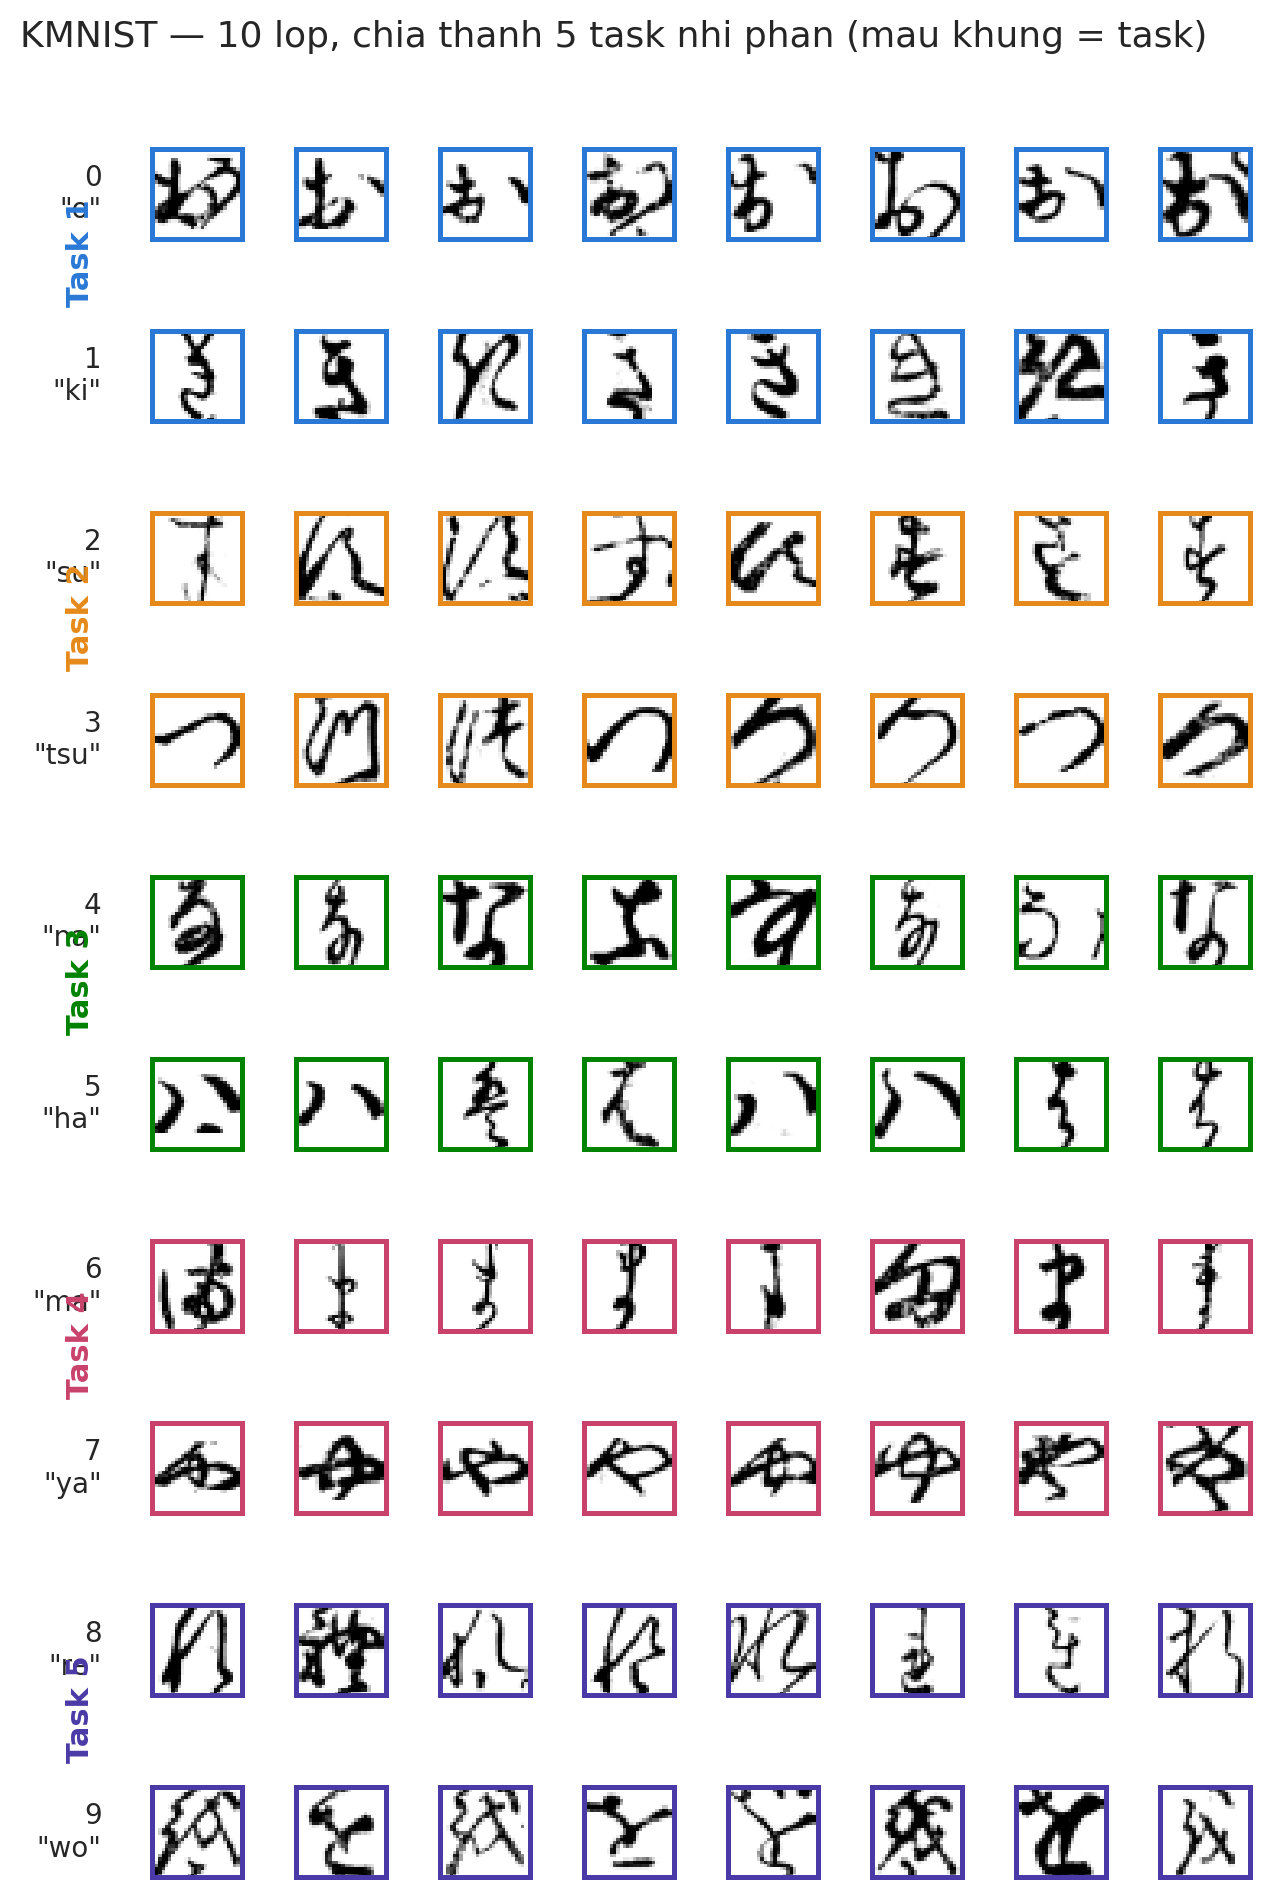

In [5]:
import torch
from torchvision import datasets, transforms

KMNIST_ROMAJI = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

raw_train = datasets.KMNIST(root='data', train=True, download=True,
                            transform=transforms.ToTensor())
raw_test  = datasets.KMNIST(root='data', train=False, download=True,
                            transform=transforms.ToTensor())
print('KMNIST train: {} anh, test: {} anh, kich thuoc {}'.format(
    len(raw_train), len(raw_test), tuple(raw_train[0][0].shape)))

labels = raw_train.targets.numpy()
n_per_class = 8
fig, axes = plt.subplots(10, n_per_class, figsize=(n_per_class * 0.85, 10 * 0.95))
task_colors = ['#2a78d6', '#e58a1a', '#008300', '#c9426c', '#4a3aa7']
for c in range(10):
    idx = np.where(labels == c)[0][:n_per_class]
    for j, ind in enumerate(idx):
        ax = axes[c, j]
        ax.imshow(raw_train.data[ind].numpy(), cmap='gray_r')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_color(task_colors[c // 2]); sp.set_linewidth(1.8)
    axes[c, 0].set_ylabel('{}\n"{}"'.format(c, KMNIST_ROMAJI[c]),
                          rotation=0, ha='right', va='center', fontsize=10, labelpad=18)
for t in range(5):
    axes[2 * t, 0].annotate('Task {}'.format(t + 1), xy=(-0.95, -0.15),
                            xycoords='axes fraction', rotation=90, fontsize=11,
                            color=task_colors[t], fontweight='bold', va='center')
fig.suptitle('KMNIST — 10 lop, chia thanh 5 task nhi phan (mau khung = task)',
             fontsize=13, y=0.995)
plt.tight_layout(rect=[0.04, 0, 1, 0.98])
p = os.path.join(FIG_DIR, '01_kmnist_samples.png')
plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
show(p, width=520)

---
## Ô 6 — Kiểm chứng hằng số chuẩn hóa

`datagen.kmnist_transforms()` dùng `Normalize((0.1918,), (0.3483,))`. Ô này tính lại
mean/std **thật** từ toàn bộ 60.000 ảnh train (47.040.000 pixel, thang `[0, 1]`) và
so sánh — dùng làm bằng chứng trong báo cáo, giống hệt phần kiểm chứng
`(0.2860, 0.3530)` của FashionMNIST.

Tinh tu toan bo 60000 anh train KMNIST (47040000 pixel, thang [0, 1]):
  mean = 0.191762   (code dung 0.1918, lech 0.000038 = 0.020%)
  std  = 0.348343   (code dung 0.3483, lech 0.000043 = 0.012%)


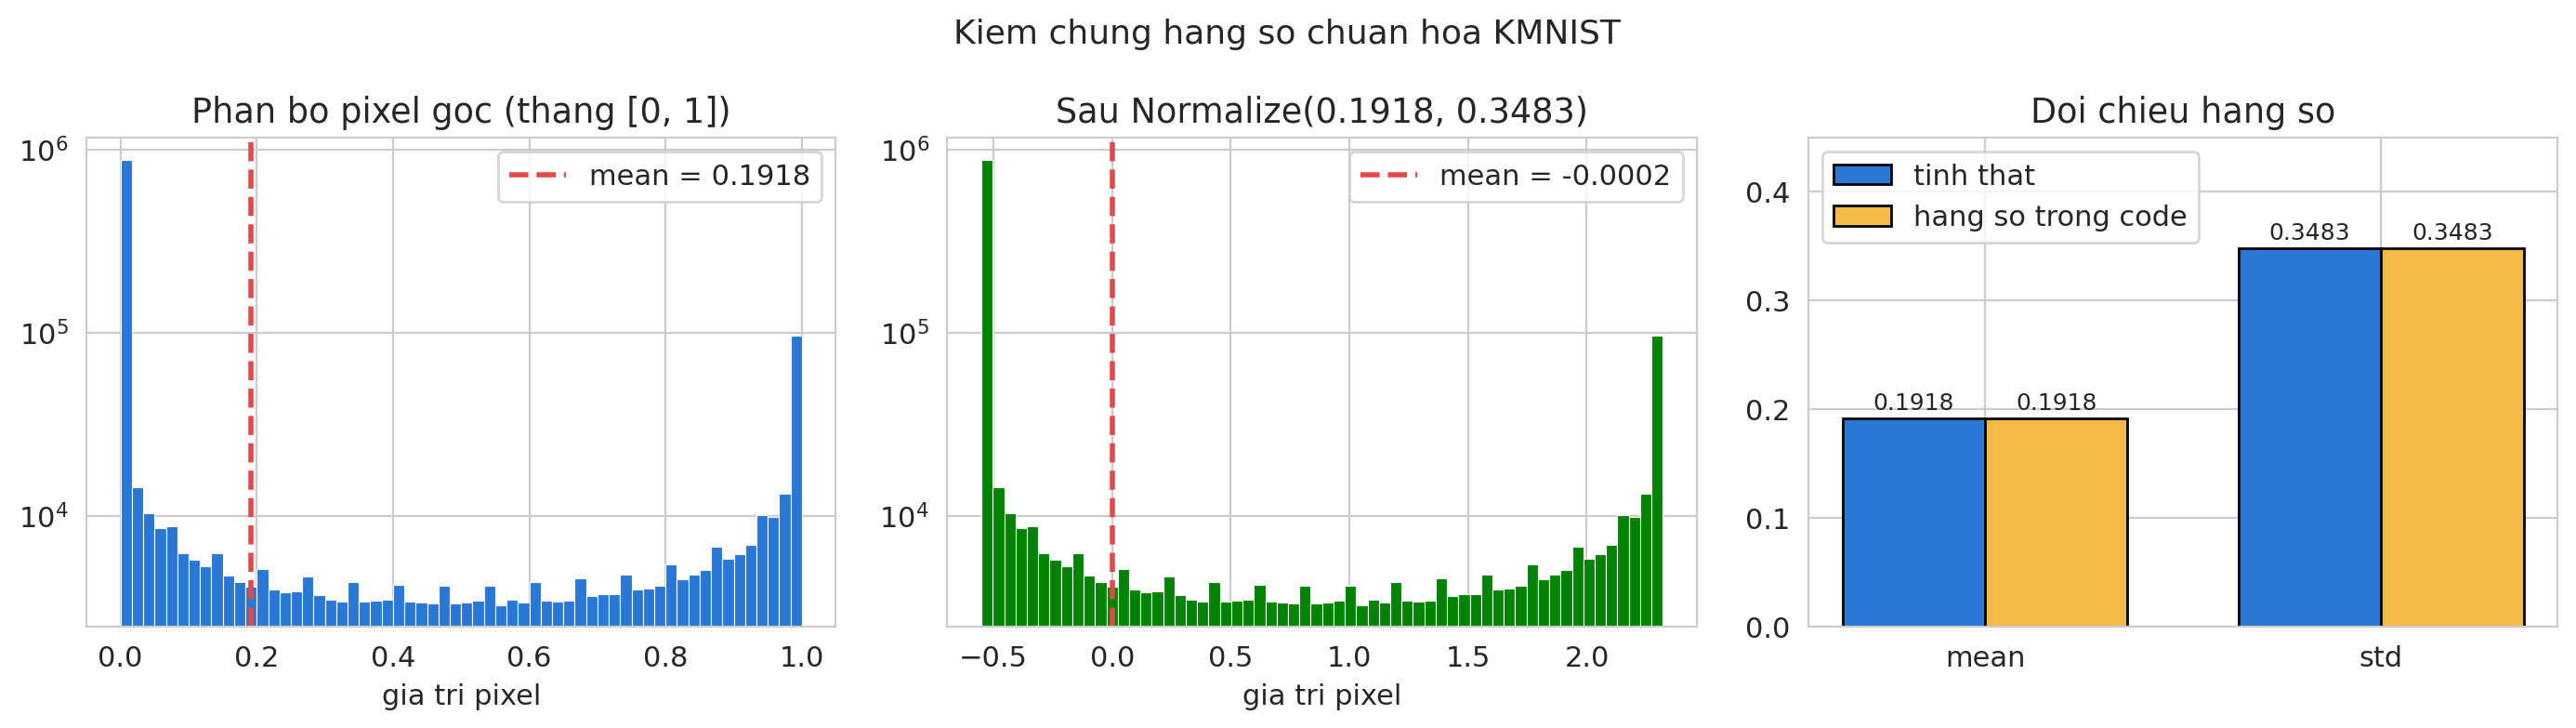

In [6]:
CODED_MEAN, CODED_STD = 0.1918, 0.3483

px = raw_train.data.numpy().astype(np.float64) / 255.0
true_mean, true_std = px.mean(), px.std()
n_px = px.size

print('Tinh tu toan bo {} anh train KMNIST ({} pixel, thang [0, 1]):'.format(len(raw_train), n_px))
print('  mean = {:.6f}   (code dung {}, lech {:.6f} = {:.3f}%)'.format(
    true_mean, CODED_MEAN, abs(true_mean - CODED_MEAN), 100 * abs(true_mean - CODED_MEAN) / true_mean))
print('  std  = {:.6f}   (code dung {}, lech {:.6f} = {:.3f}%)'.format(
    true_std, CODED_STD, abs(true_std - CODED_STD), 100 * abs(true_std - CODED_STD) / true_std))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(px.ravel()[::37], bins=60, color='#2a78d6', edgecolor='white', linewidth=0.4)
axes[0].axvline(true_mean, color='#e34948', linestyle='--', linewidth=2,
                label='mean = {:.4f}'.format(true_mean))
axes[0].set_title('Phan bo pixel goc (thang [0, 1])'); axes[0].set_yscale('log')
axes[0].set_xlabel('gia tri pixel'); axes[0].legend()

norm_px = (px.ravel()[::37] - CODED_MEAN) / CODED_STD
axes[1].hist(norm_px, bins=60, color='#008300', edgecolor='white', linewidth=0.4)
axes[1].axvline(norm_px.mean(), color='#e34948', linestyle='--', linewidth=2,
                label='mean = {:.4f}'.format(norm_px.mean()))
axes[1].set_title('Sau Normalize(0.1918, 0.3483)'); axes[1].set_yscale('log')
axes[1].set_xlabel('gia tri pixel'); axes[1].legend()

x = np.arange(2)
axes[2].bar(x - 0.18, [true_mean, true_std], width=0.36, label='tinh that',
            color='#2a78d6', edgecolor='black')
axes[2].bar(x + 0.18, [CODED_MEAN, CODED_STD], width=0.36, label='hang so trong code',
            color='#f4b942', edgecolor='black')
for xi, (a, b) in enumerate([(true_mean, CODED_MEAN), (true_std, CODED_STD)]):
    axes[2].text(xi - 0.18, a + 0.008, '{:.4f}'.format(a), ha='center', fontsize=9)
    axes[2].text(xi + 0.18, b + 0.008, '{:.4f}'.format(b), ha='center', fontsize=9)
axes[2].set_xticks(x); axes[2].set_xticklabels(['mean', 'std'])
axes[2].set_ylim(0, 0.45); axes[2].set_title('Doi chieu hang so'); axes[2].legend()

fig.suptitle('Kiem chung hang so chuan hoa KMNIST', fontsize=13)
plt.tight_layout()
p = os.path.join(FIG_DIR, '02_kmnist_normalization.png')
plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
show(p)

---
## Ô 7 — Continual Learning: 16 phương pháp (Table 3, §5.3)

Giao thức đúng như bài báo: **single-head**, 5 task, mỗi task lấy 1000 điểm,
replay buffer `m = 100` dùng chung cho mọi task (task thứ *t* được cấp `⌊m/t⌋` chỗ),
huấn luyện 400 epoch bằng Adam `5e-4` sau mỗi task.

- `coreset` = BiCo qua **proxy NTK** (§3.5.2) — đúng biến thể bài báo dùng cho Table 3.
- `forgetting`, `sensitivity`, `glister` là 3 baseline repo tự thêm, ngoài 13 phương pháp gốc.

Vì `samples_per_task = 1000`, chi phí ở đây **không phụ thuộc kích thước bộ dữ liệu** —
KMNIST 60k tốn đúng bằng FashionMNIST 60k.

⏱️ Khoảng 60–90 phút.

In [7]:
t_start = time.time()
for method in CL_METHODS:
    run([sys.executable, 'cl.py',
         '--dataset', DATASET, '--method', method, '--seed', str(SEED),
         '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA)],
        cwd=CL_DIR, label='CL  {:<18} seed={}'.format(method, SEED))
print('\ntong: {:.1f} phut'.format((time.time() - t_start) / 60))

[ok      91.0s] CL  uniform            seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='uniform', device
[ok     144.3s] CL  coreset            seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='coreset', device
[ok      85.8s] CL  kmeans_features    seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='kmeans_features'
[ok      85.5s] CL  kcenter_features   seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='kcenter_features
[ok      86.3s] CL  kmeans_embedding   seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='kmeans_embedding
[ok      87.8s] CL  kcenter_embedding  seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='kcenter_embeddin
[ok      91.1s] CL  kmeans_grads       seed=0  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='kmeans_grads', d
[ok      92.4

### Bảng kết quả Table 3 (đọc trực tiếp từ file JSON)

`Average Forgetting` tính theo công thức chuẩn của continual learning:
với mỗi task cũ, lấy độ chính xác **tốt nhất từng đạt được** trừ đi độ chính xác
**ở cuối chuỗi**, rồi lấy trung bình.

In [8]:
def average_forgetting(acc_matrix):
    m = np.array(acc_matrix)
    n = m.shape[0]
    return float(np.mean([m[:n - 1, k].max() - m[n - 1][k] for k in range(n - 1)]))

def load_cl(dataset, method, buffer_size=BUFFER_SIZE, beta=BETA, seed=SEED):
    path = os.path.join(CL_DIR, 'cl_results',
                        '{}_{}_{}_{}_{}.txt'.format(dataset, method, buffer_size, beta, seed))
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    d['forgetting'] = average_forgetting(d['acc_matrix']) if 'acc_matrix' in d else float('nan')
    return d

rows = []
for m in CL_METHODS:
    d = load_cl(DATASET, m)
    rows.append((m, d['test_acc'], d['forgetting'], d['execution_time']) if d else (m, None, None, None))

rows_ok = [r for r in rows if r[1] is not None]
best = max(r[1] for r in rows_ok) if rows_ok else 0
print('{:<20} {:>9} {:>13} {:>12}'.format('Phuong phap', 'Acc (%)', 'Forgetting', 'Time (s)'))
print('-' * 58)
for name, acc, fg, tm in rows:
    if acc is None:
        print('{:<20} {:>9}'.format(name, 'chua chay'))
    else:
        print('{:<20} {:>9.2f} {:>13.2f} {:>12.1f}{}'.format(
            name, acc, fg, tm, '  <-- tot nhat' if acc == best else ''))

Phuong phap            Acc (%)    Forgetting     Time (s)
----------------------------------------------------------
uniform                  67.14         35.21         64.8
coreset                  69.94         31.49        110.4
kmeans_features          61.67         42.54         66.7
kcenter_features         51.58         55.11         67.2
kmeans_embedding         66.36         36.75         67.8
kcenter_embedding        71.16         29.69         68.9  <-- tot nhat
kmeans_grads             66.67         36.06         72.1
kcenter_grads            65.54         36.94         73.6
grad_matching            62.83         41.39         73.7
entropy                  61.61         41.16         65.4
hardest                  58.82         45.84         66.2
frcl                     65.58         37.21        129.9
icarl                    66.29         37.19         68.0
forgetting               57.99         46.76         68.8
sensitivity              63.78         39.92         66.4

---
## Ô 8 — Ba biểu đồ so sánh baseline

Dùng `experiments/baseline_comparison_plot.py` với **`--seeds 0`**.

> ⚠️ **Lưu ý về tính trung thực số liệu.** Script này **bịa số minh họa** (đánh dấu `*`
> trên biểu đồ) cho 5 phương pháp `uniform / kmeans_features / sensitivity / glister /
> coreset` **nếu không tìm thấy file kết quả nào**. Ô 7 đã chạy đủ mọi phương pháp ở
> seed 0 nên các cột dưới đây là **số thật** — hãy kiểm tra lại: **không được có dấu `*`
> nào trên hình**.
>
> 📌 Biểu đồ chỉ hiển thị **15/16** phương pháp: `forgetting` (Toneva et al., 2019)
> không có trong từ điển `METHODS` của script vẽ nên bị bỏ qua. Số của nó nằm trong
> **bảng ở Ô 7**.

[ok       3.0s] bieu do accuracy  |  Đã lưu biểu đồ So sánh Độ chính xác tại: /kaggle/working/bilevel-coresets/experiments/base
[ok       2.7s] bieu do forgetting  |  Đã lưu biểu đồ So sánh Forgetting tại: /kaggle/working/bilevel-coresets/experiments/baseli
[ok       2.8s] bieu do trade-off  |  Đã lưu biểu đồ Trade-off tại: /kaggle/working/bilevel-coresets/experiments/baseline_tradeo


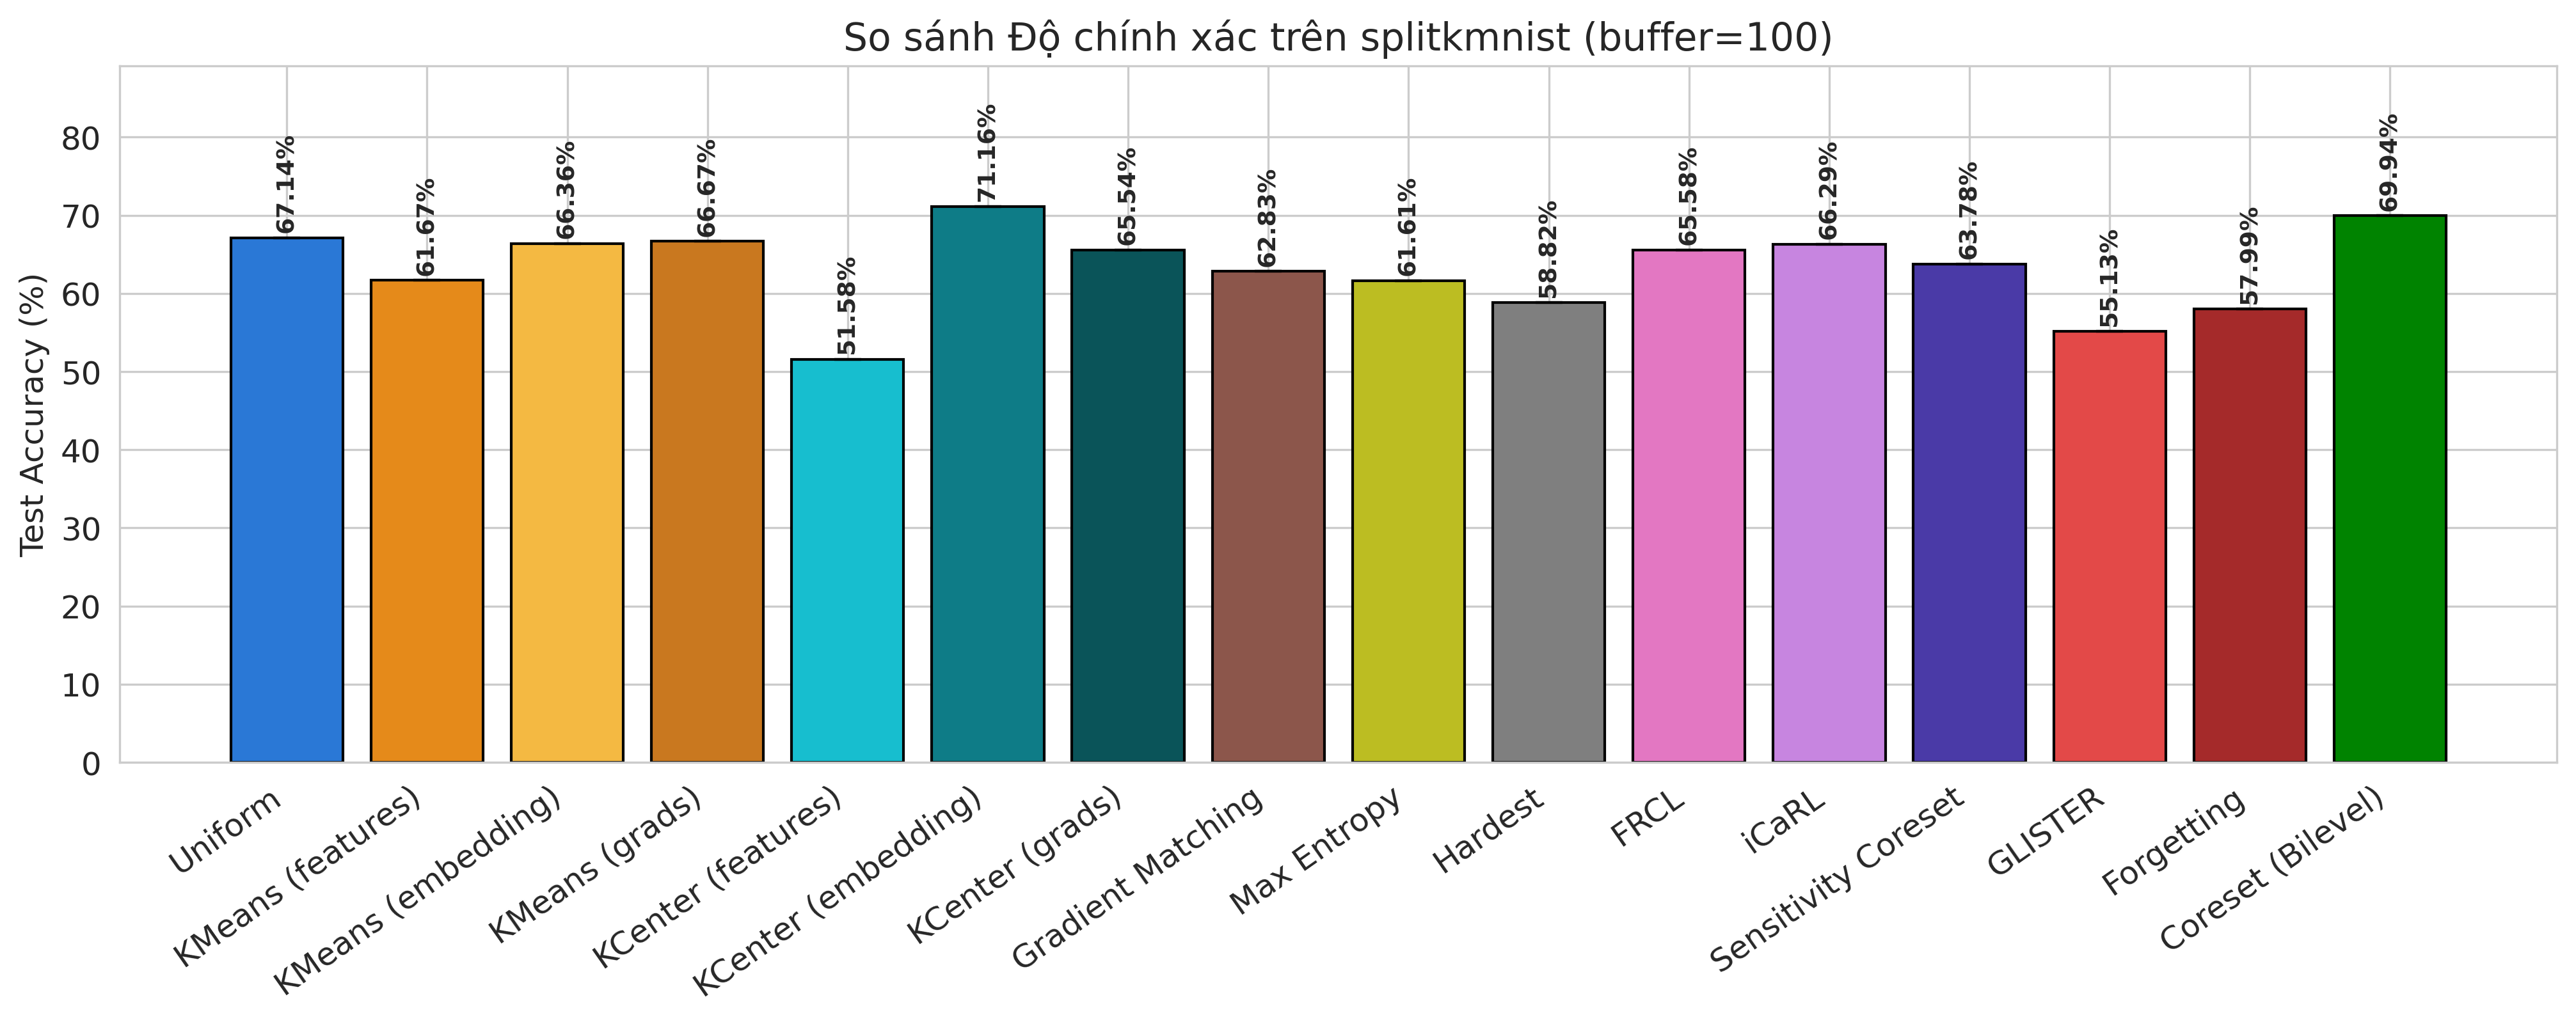

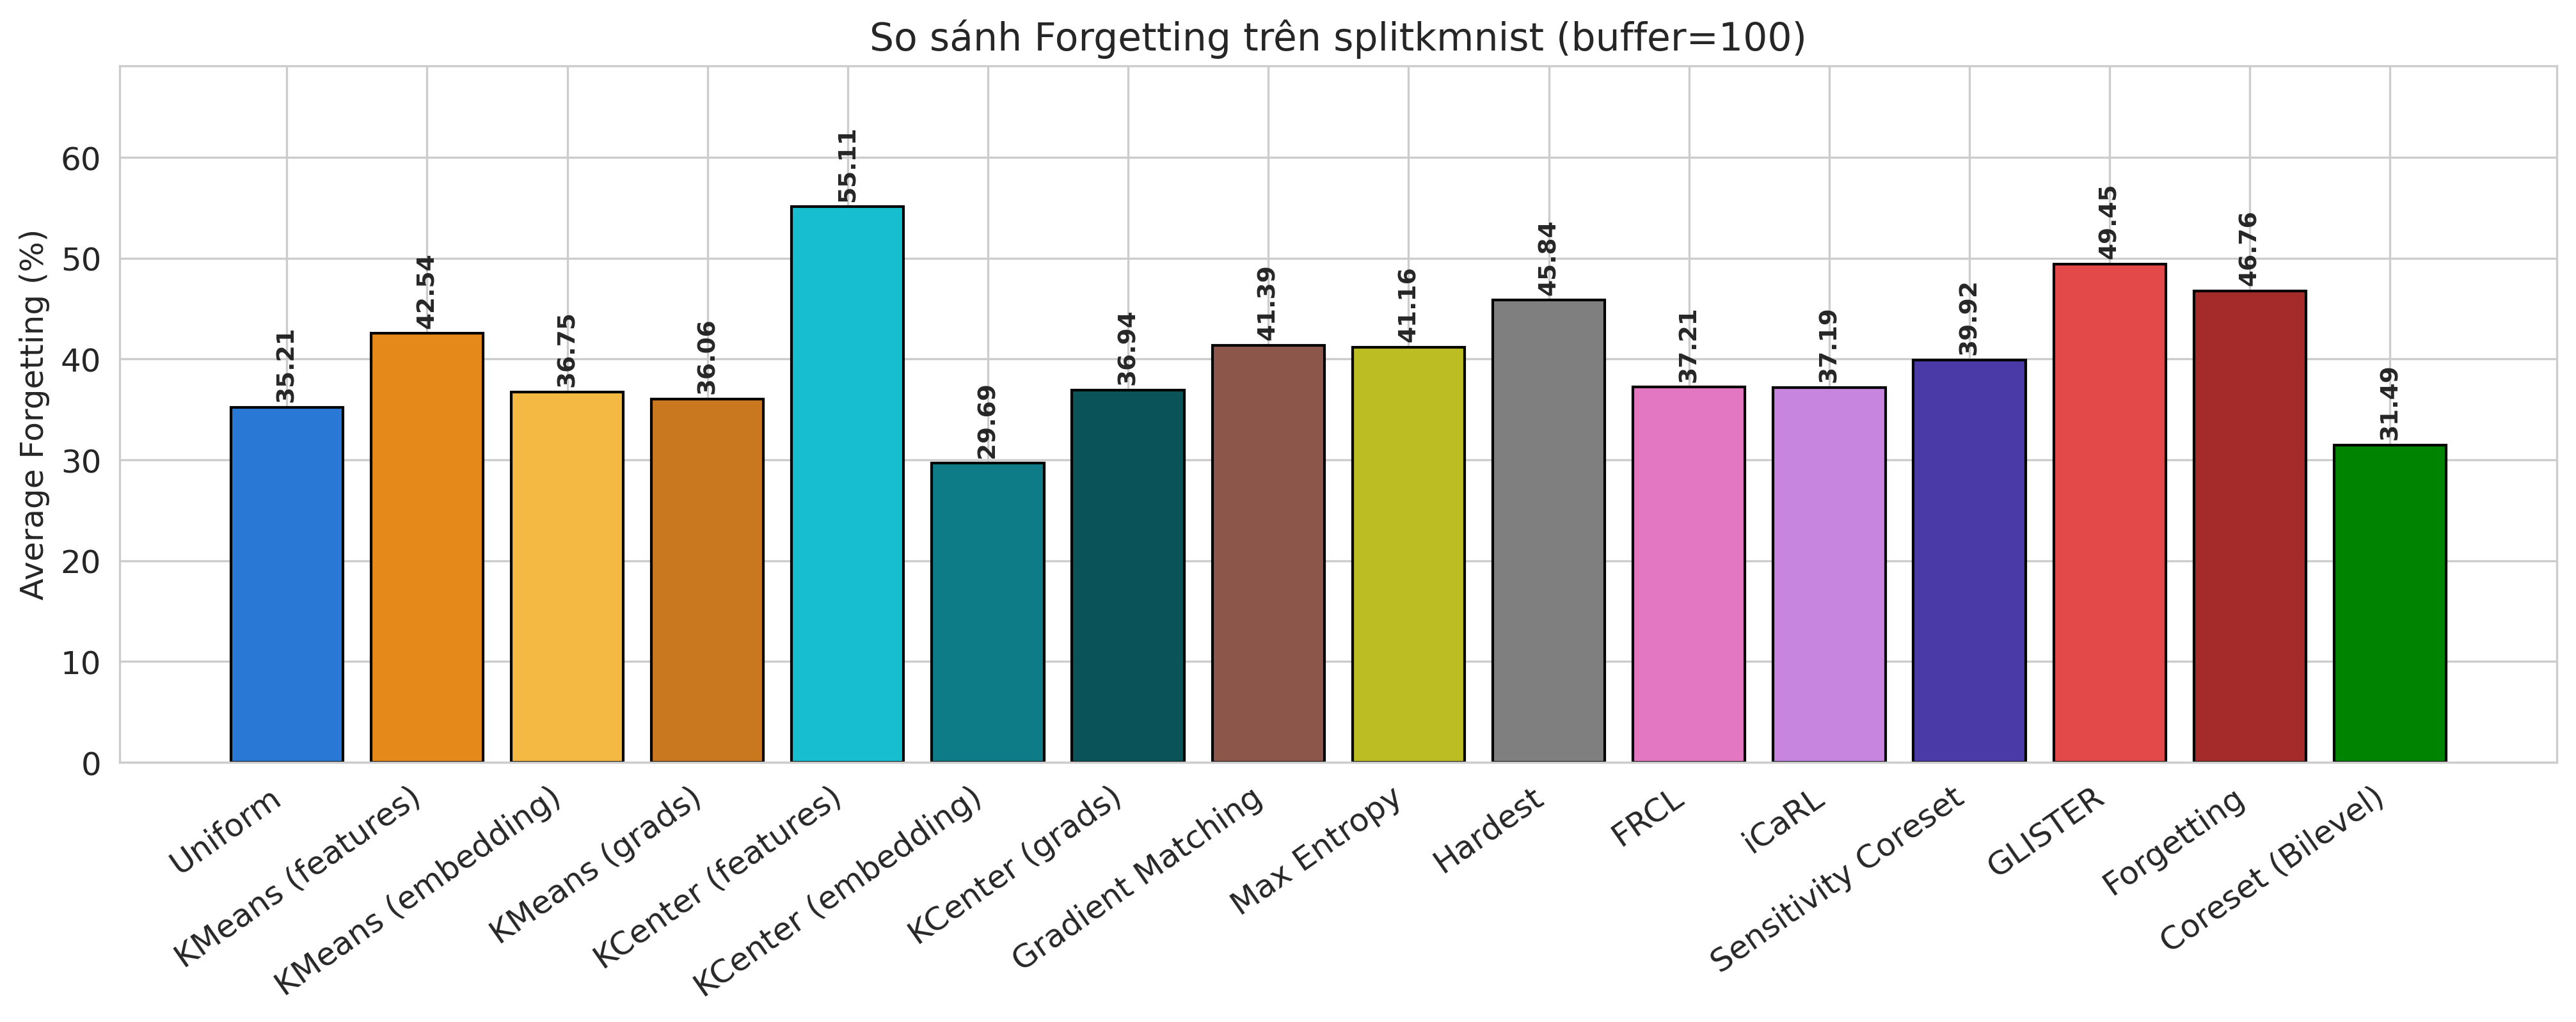

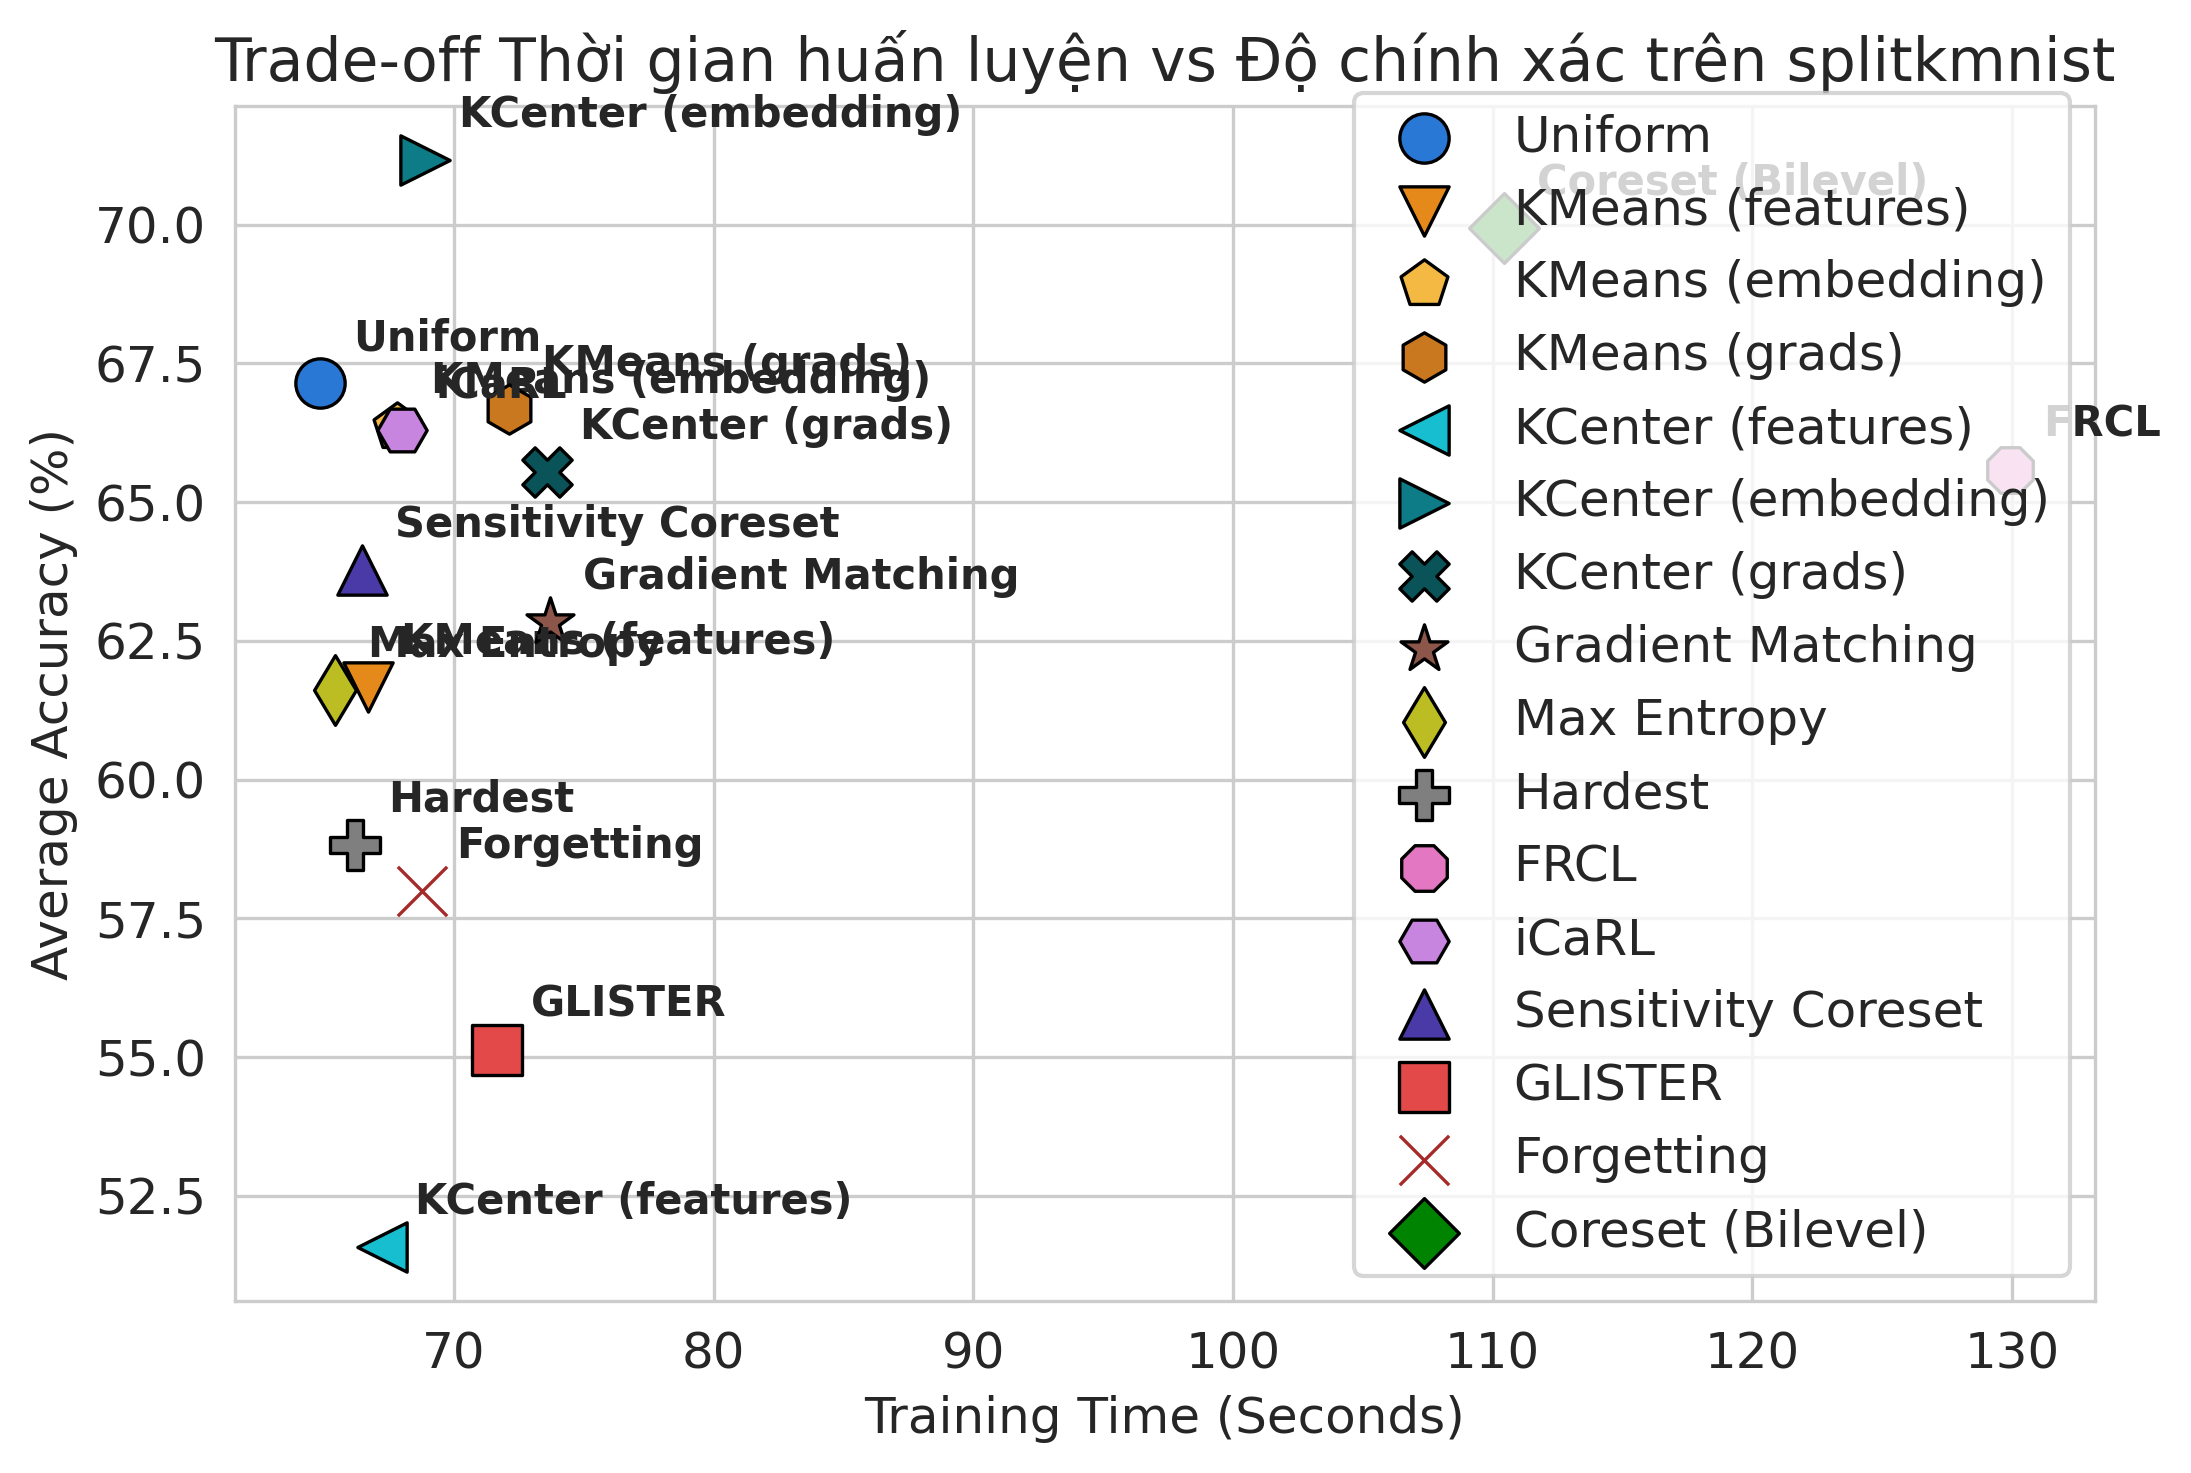

In [9]:
run([sys.executable, os.path.join(EXP_DIR, 'baseline_comparison_plot.py'),
     '--plot', 'accuracy', '--dataset', DATASET,
     '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA), '--seeds', str(SEED)],
    cwd=REPO, label='bieu do accuracy')
run([sys.executable, os.path.join(EXP_DIR, 'baseline_comparison_plot.py'),
     '--plot', 'forgetting', '--dataset', DATASET,
     '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA), '--seeds', str(SEED)],
    cwd=REPO, label='bieu do forgetting')
run([sys.executable, os.path.join(EXP_DIR, 'baseline_comparison_plot.py'),
     '--plot', 'tradeoff', '--dataset', DATASET,
     '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA), '--seeds', str(SEED)],
    cwd=REPO, label='bieu do trade-off')

# script luu ra ten file co dinh (khong kem ten dataset) -> doi ten de khong
# de bi ghi de neu sau nay chay lai voi FashionMNIST trong cung phien lam viec
for src_name, dst_name in [
    ('baseline_accuracy_comparison.png',   '03_cl_accuracy.png'),
    ('baseline_forgetting_comparison.png', '04_cl_forgetting.png'),
    ('baseline_tradeoff_comparison.png',   '05_cl_tradeoff.png'),
]:
    src = os.path.join(EXP_DIR, src_name)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(FIG_DIR, dst_name))
        show(os.path.join(FIG_DIR, dst_name))

---
## Ô 9 — Ablation: buffer size và β

Bài báo (Appendix D, Table 9) cho thấy **lợi thế của BiCo càng lớn khi buffer càng nhỏ**
— trên SMNIST, BiCo hơn uniform 6,4 điểm ở `m=50` nhưng chỉ 1,9 điểm ở `m=200`.
Ô này chạy đủ số liệu thật để kiểm tra điều đó trên KMNIST.

Cần 4 lần chạy bổ sung (`buffer ∈ {50, 200}` ở `β=1.0`, và `β ∈ {0.01, 100}` ở
`buffer=100`); điểm `(100, 1.0)` đã có từ Ô 7. Chạy thêm `uniform` ở cùng các
buffer size để có đường đối chiếu.

> ⚠️ Nếu bỏ qua ô này, biểu đồ ablation của `baseline_comparison_plot.py` sẽ
> **dùng số minh họa bịa sẵn** — đúng cái bẫy đã xảy ra ở notebook FashionMNIST trước.

⏱️ Khoảng 30–40 phút.

In [10]:
for bs in [50, 200]:
    for method in ['coreset', 'uniform']:
        run([sys.executable, 'cl.py', '--dataset', DATASET, '--method', method,
             '--seed', str(SEED), '--buffer_size', str(bs), '--beta', str(BETA)],
            cwd=CL_DIR, label='ablation buffer={:<4} {}'.format(bs, method))

for beta in [0.01, 100.0]:
    run([sys.executable, 'cl.py', '--dataset', DATASET, '--method', 'coreset',
         '--seed', str(SEED), '--buffer_size', str(BUFFER_SIZE), '--beta', str(beta)],
        cwd=CL_DIR, label='ablation beta={:<6} coreset'.format(beta))

[ok     108.7s] ablation buffer=50   coreset  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='coreset', device
[ok      82.4s] ablation buffer=50   uniform  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='uniform', device
[ok     187.2s] ablation buffer=200  coreset  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='coreset', device
[ok      92.9s] ablation buffer=200  uniform  |  Namespace(seed=0, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='uniform', device
[ok     131.6s] ablation beta=0.01   coreset  |  Namespace(seed=0, nr_epochs=400, beta=0.01, dataset='splitkmnist', method='coreset', devic
[ok     130.4s] ablation beta=100.0  coreset  |  Namespace(seed=0, nr_epochs=400, beta=100.0, dataset='splitkmnist', method='coreset', devi


[ok       3.1s] bieu do ablation  |  Đã lưu biểu đồ Ablation tại: /kaggle/working/bilevel-coresets/experiments/coreset_ablation


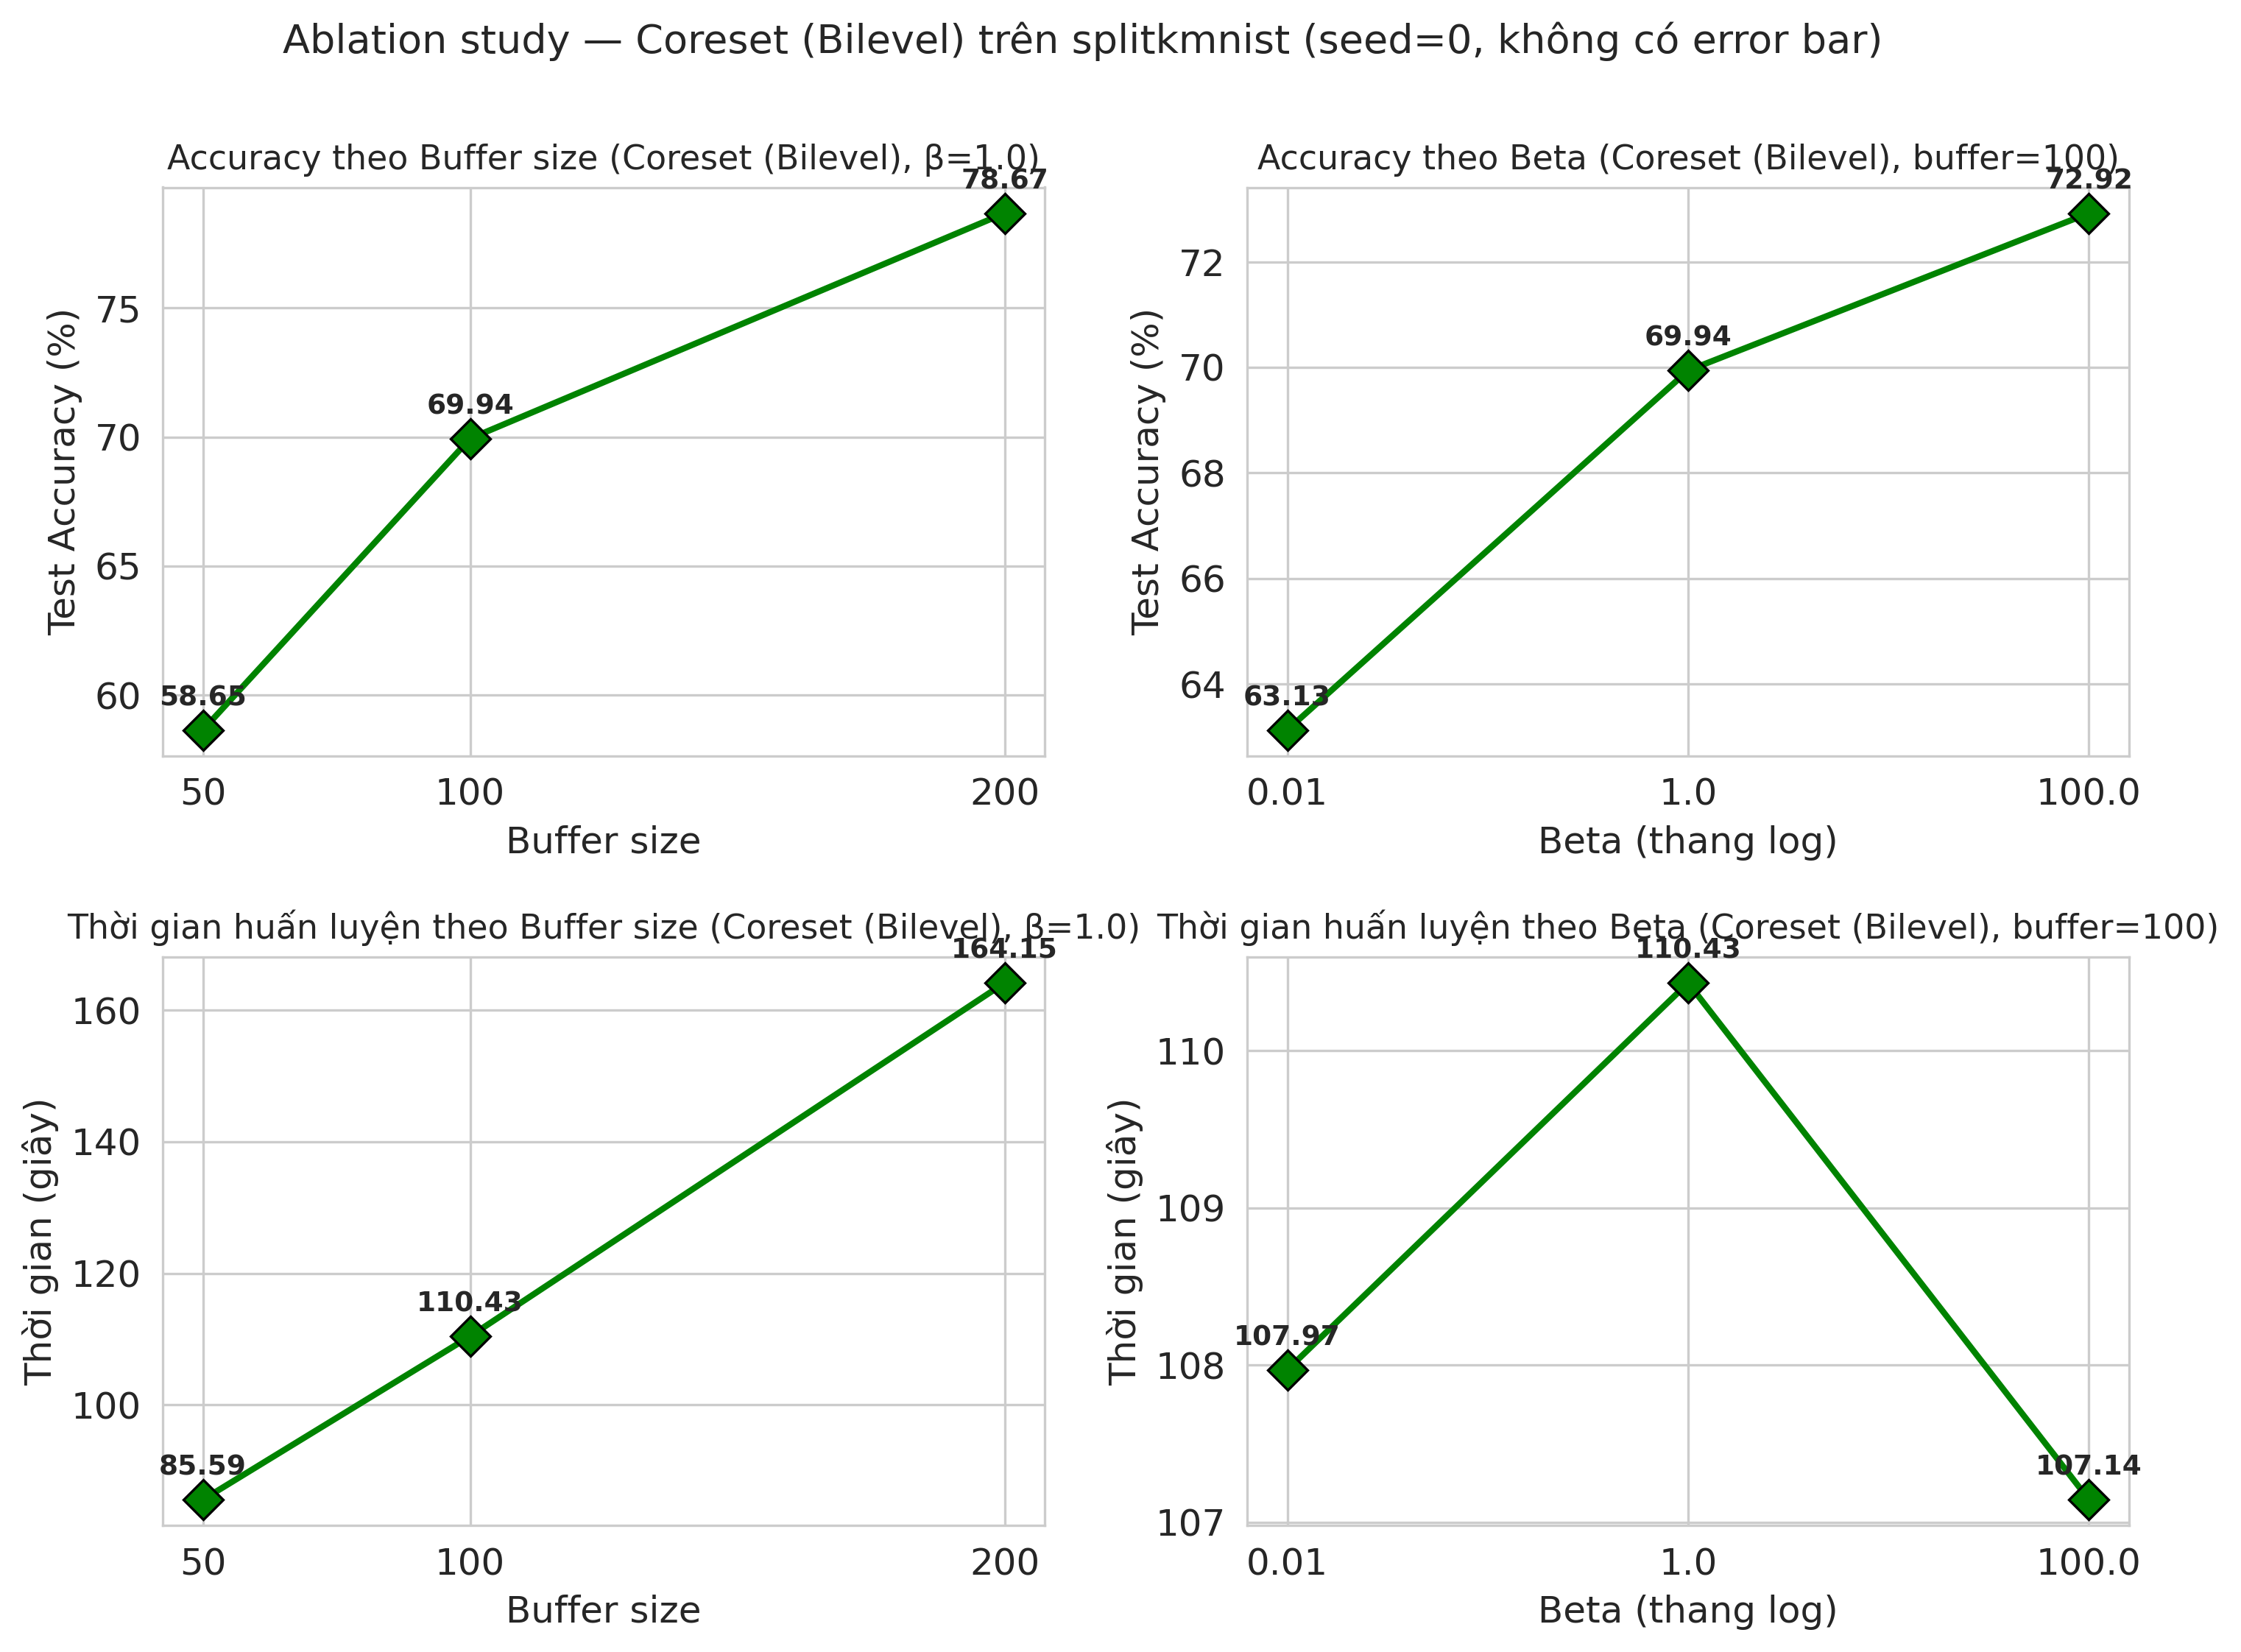


BiCo vs Uniform theo buffer size (beta=1.0, seed=0):
  buffer    uniform    coreset chenh lech
      50      48.57      58.65     +10.08
     100      67.14      69.94      +2.80
     200      75.65      78.67      +3.02


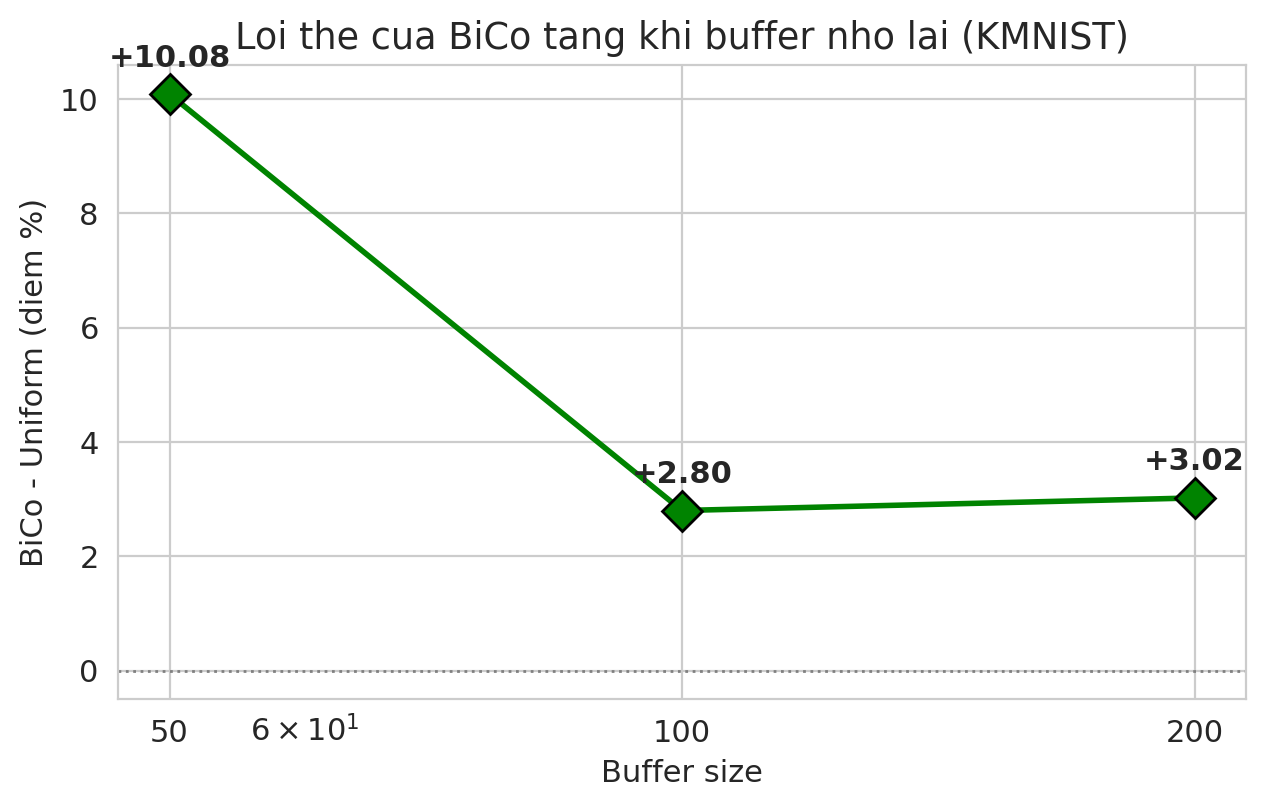

In [11]:
run([sys.executable, os.path.join(EXP_DIR, 'baseline_comparison_plot.py'),
     '--plot', 'ablation', '--dataset', DATASET,
     '--ablation_method', 'coreset', '--ablation_seed', str(SEED)],
    cwd=REPO, label='bieu do ablation')
src = os.path.join(EXP_DIR, 'coreset_ablation.png')
if os.path.exists(src):
    shutil.copy(src, os.path.join(FIG_DIR, '06_ablation.png'))
    show(os.path.join(FIG_DIR, '06_ablation.png'))

# Doi chieu truc tiep BiCo vs Uniform theo buffer size (kiem tra Table 9)
print('\nBiCo vs Uniform theo buffer size (beta=1.0, seed={}):'.format(SEED))
print('{:>8} {:>10} {:>10} {:>10}'.format('buffer', 'uniform', 'coreset', 'chenh lech'))
gap_x, gap_y = [], []
for bs in [50, 100, 200]:
    u, c = load_cl(DATASET, 'uniform', buffer_size=bs), load_cl(DATASET, 'coreset', buffer_size=bs)
    if u and c:
        print('{:>8} {:>10.2f} {:>10.2f} {:>+10.2f}'.format(bs, u['test_acc'], c['test_acc'],
                                                            c['test_acc'] - u['test_acc']))
        gap_x.append(bs); gap_y.append(c['test_acc'] - u['test_acc'])
    else:
        print('{:>8} {:>10}'.format(bs, 'thieu file'))

if gap_x:
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(gap_x, gap_y, marker='D', markersize=10, color='#008300',
            markeredgecolor='black', linewidth=2)
    for x, y in zip(gap_x, gap_y):
        ax.annotate('{:+.2f}'.format(y), (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontweight='semibold')
    ax.axhline(0, color='gray', linewidth=1, linestyle=':')
    ax.set_xscale('log'); ax.set_xticks(gap_x); ax.set_xticklabels([str(v) for v in gap_x])
    ax.set_xlabel('Buffer size'); ax.set_ylabel('BiCo - Uniform (diem %)')
    ax.set_title('Loi the cua BiCo tang khi buffer nho lai (KMNIST)')
    plt.tight_layout()
    p = os.path.join(FIG_DIR, '07_gap_vs_buffer.png')
    plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
    show(p, width=650)

---
## Ô 10 — Nhiều seed: error bar cho Uniform vs BiCo

Kết quả một seed **không đủ** để khẳng định chênh lệch vài phần trăm là thật.
Ô này chạy thêm seed 1 và 2 cho hai phương pháp quan trọng nhất
(`uniform` là mốc, `coreset` là phương pháp của bài báo) để có độ lệch chuẩn thật.

⏱️ Khoảng 20–25 phút.

In [12]:
for seed in EXTRA_SEEDS:
    for method in MULTI_SEED_METHODS:
        run([sys.executable, 'cl.py', '--dataset', DATASET, '--method', method,
             '--seed', str(seed), '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA)],
            cwd=CL_DIR, label='CL  {:<18} seed={}'.format(method, seed))

[ok      84.3s] CL  uniform            seed=1  |  Namespace(seed=1, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='uniform', device
[ok     135.4s] CL  coreset            seed=1  |  Namespace(seed=1, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='coreset', device
[ok      86.1s] CL  uniform            seed=2  |  Namespace(seed=2, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='uniform', device
[ok     133.1s] CL  coreset            seed=2  |  Namespace(seed=2, nr_epochs=400, beta=1.0, dataset='splitkmnist', method='coreset', device


Trung binh tren 3 seed:
  uniform    66.64 +/- 1.12  (n=3)  ['67.14', '65.09', '67.68']
  coreset    71.61 +/- 1.19  (n=3)  ['69.94', '72.32', '72.57']

Chenh lech BiCo - Uniform = +4.97 diem (do lech gop 1.63)
=> chenh lech LON HON nhieu so voi bien dong giua cac seed


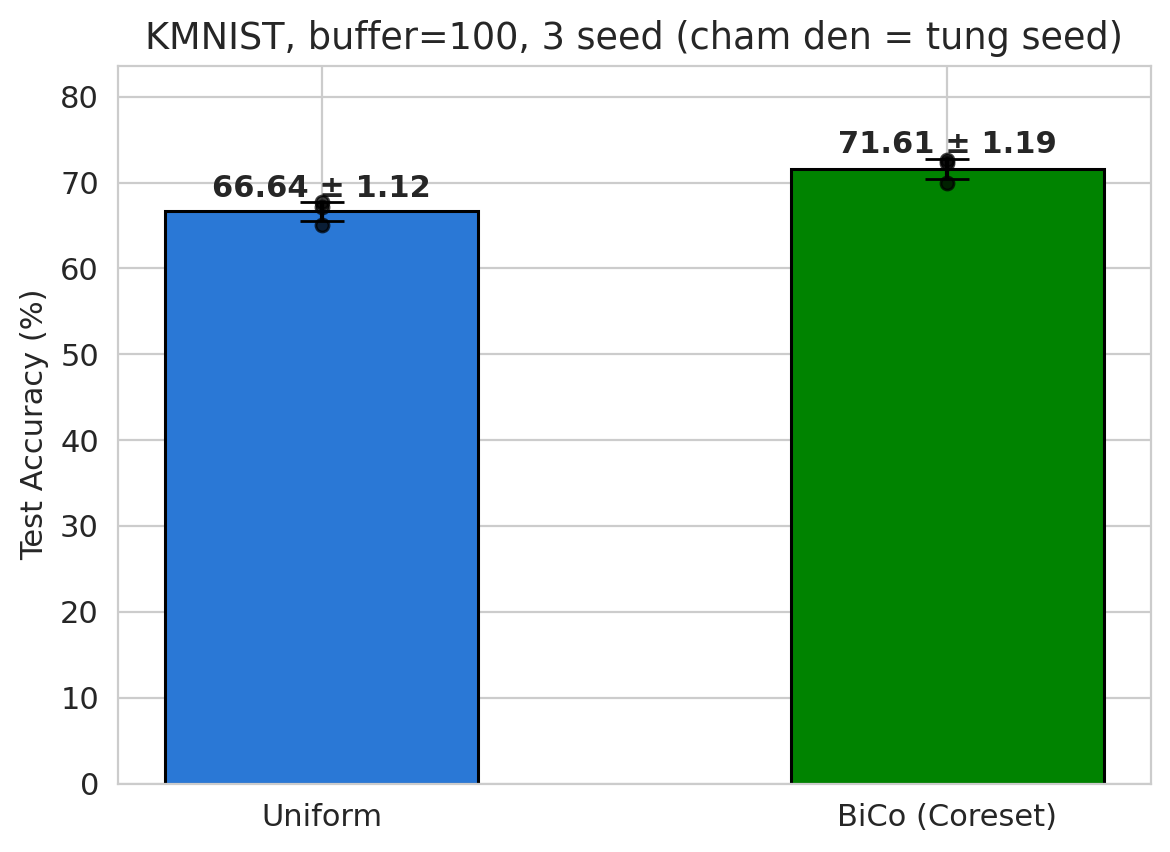

In [13]:
all_seeds = [SEED] + EXTRA_SEEDS
stats = {}
for method in MULTI_SEED_METHODS:
    accs = [d['test_acc'] for d in (load_cl(DATASET, method, seed=s) for s in all_seeds) if d]
    if accs:
        stats[method] = (float(np.mean(accs)), float(np.std(accs)), len(accs), accs)

print('Trung binh tren {} seed:'.format(len(all_seeds)))
for m, (mu, sd, n, accs) in stats.items():
    print('  {:<10} {:.2f} +/- {:.2f}  (n={})  {}'.format(
        m, mu, sd, n, ['{:.2f}'.format(a) for a in accs]))

if len(stats) == 2:
    u, c = stats['uniform'], stats['coreset']
    gap = c[0] - u[0]
    pooled = float(np.sqrt(u[1] ** 2 + c[1] ** 2))
    print('\nChenh lech BiCo - Uniform = {:+.2f} diem (do lech gop {:.2f})'.format(gap, pooled))
    print('=> {}'.format('chenh lech LON HON nhieu so voi bien dong giua cac seed'
                         if abs(gap) > 2 * pooled else
                         'CHUA the ket luan chac chan -- can them seed'))

    fig, ax = plt.subplots(figsize=(6, 4.4))
    names = ['Uniform', 'BiCo (Coreset)']
    means = [u[0], c[0]]; stds = [u[1], c[1]]
    bars = ax.bar(names, means, yerr=stds, capsize=8, width=0.5,
                  color=['#2a78d6', '#008300'], edgecolor='black', linewidth=1.1)
    for bar, mu, sd, (_, _, _, accs) in zip(bars, means, stds, [u, c]):
        ax.text(bar.get_x() + bar.get_width() / 2, mu + sd + 0.6,
                '{:.2f} ± {:.2f}'.format(mu, sd), ha='center', fontweight='semibold')
        ax.scatter([bar.get_x() + bar.get_width() / 2] * len(accs), accs,
                   color='black', zorder=5, s=22, alpha=0.75)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_ylim(0, max(means) + 12)
    ax.set_title('KMNIST, buffer={}, {} seed (cham den = tung seed)'.format(
        BUFFER_SIZE, len(all_seeds)))
    plt.tight_layout()
    p = os.path.join(FIG_DIR, '08_multiseed.png')
    plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
    show(p, width=620)

---
## Ô 11 — Streaming: Table 5 (cân bằng) và Table 6 (mất cân bằng)

Khác continual learning, streaming **không có ranh giới task** và không giả định i.i.d.
Buffer được quản lý bằng khung **merge-reduce** (§4.2): hai coreset được gộp thành một
bằng cách chạy lại bài toán bilevel với outer objective là loss trên hợp của chúng.

- **Table 5 — cân bằng** (`nr_slots=10`): `reservoir`, `cbrs`, `coreset`.
- **Table 6 — mất cân bằng** (`nr_slots=1`): 4 task đầu chỉ giữ 200 điểm, task cuối giữ 2000.

> 📌 **Sửa lỗi so với notebook FashionMNIST trước:** notebook cũ chỉ chạy
> `reservoir` và `cbrs` cho Table 6 vì cho rằng bài báo không so `coreset` ở đây.
> Thực tế **Table 6 của bài báo có đủ 3 dòng** và BiCo *thắng* trên SMNIST
> (reservoir 80.60, CBRS 89.71, **BiCo 92.37**). Ô này chạy đủ cả 3.

⏱️ Khoảng 25–35 phút.

In [14]:
print('--- Table 5: streaming can bang (nr_slots=10) ---')
for method in ['reservoir', 'cbrs', 'coreset']:
    run([sys.executable, 'streaming.py', '--dataset', DATASET, '--method', method,
         '--seed', str(SEED), '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA)],
        cwd=CL_DIR, label='stream can bang    {:<10}'.format(method))

print('\n--- Table 6: streaming mat can bang (nr_slots=1) ---')
for method in ['reservoir', 'cbrs', 'coreset']:
    run([sys.executable, 'streaming.py', '--dataset', DATASET_IMB, '--method', method,
         '--seed', str(SEED), '--buffer_size', str(BUFFER_SIZE), '--beta', str(BETA),
         '--nr_slots', '1'],
        cwd=CL_DIR, label='stream mat can bang {:<10}'.format(method))

--- Table 5: streaming can bang (nr_slots=10) ---
[ok      28.5s] stream can bang    reservoir   |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnist', method='reservoir', devic
[ok      28.6s] stream can bang    cbrs        |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnist', method='cbrs', device='cu
[ok     114.7s] stream can bang    coreset     |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnist', method='coreset', device=

--- Table 6: streaming mat can bang (nr_slots=1) ---
[ok      24.4s] stream mat can bang reservoir   |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnistimbalanced', method='reservo
[ok      24.1s] stream mat can bang cbrs        |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnistimbalanced', method='cbrs', 
[ok    1325.9s] stream mat can bang coreset     |  Namespace(seed=0, nr_epochs=40, beta=1.0, dataset='splitkmnistimbalanced', method='coreset


                 Table 5 (can bang) Table 6 (mat can bang)
------------------------------------------------------
Reservoir                     65.52              43.10
CBRS                          59.17              56.44
BiCo (Coreset)                61.17              57.98


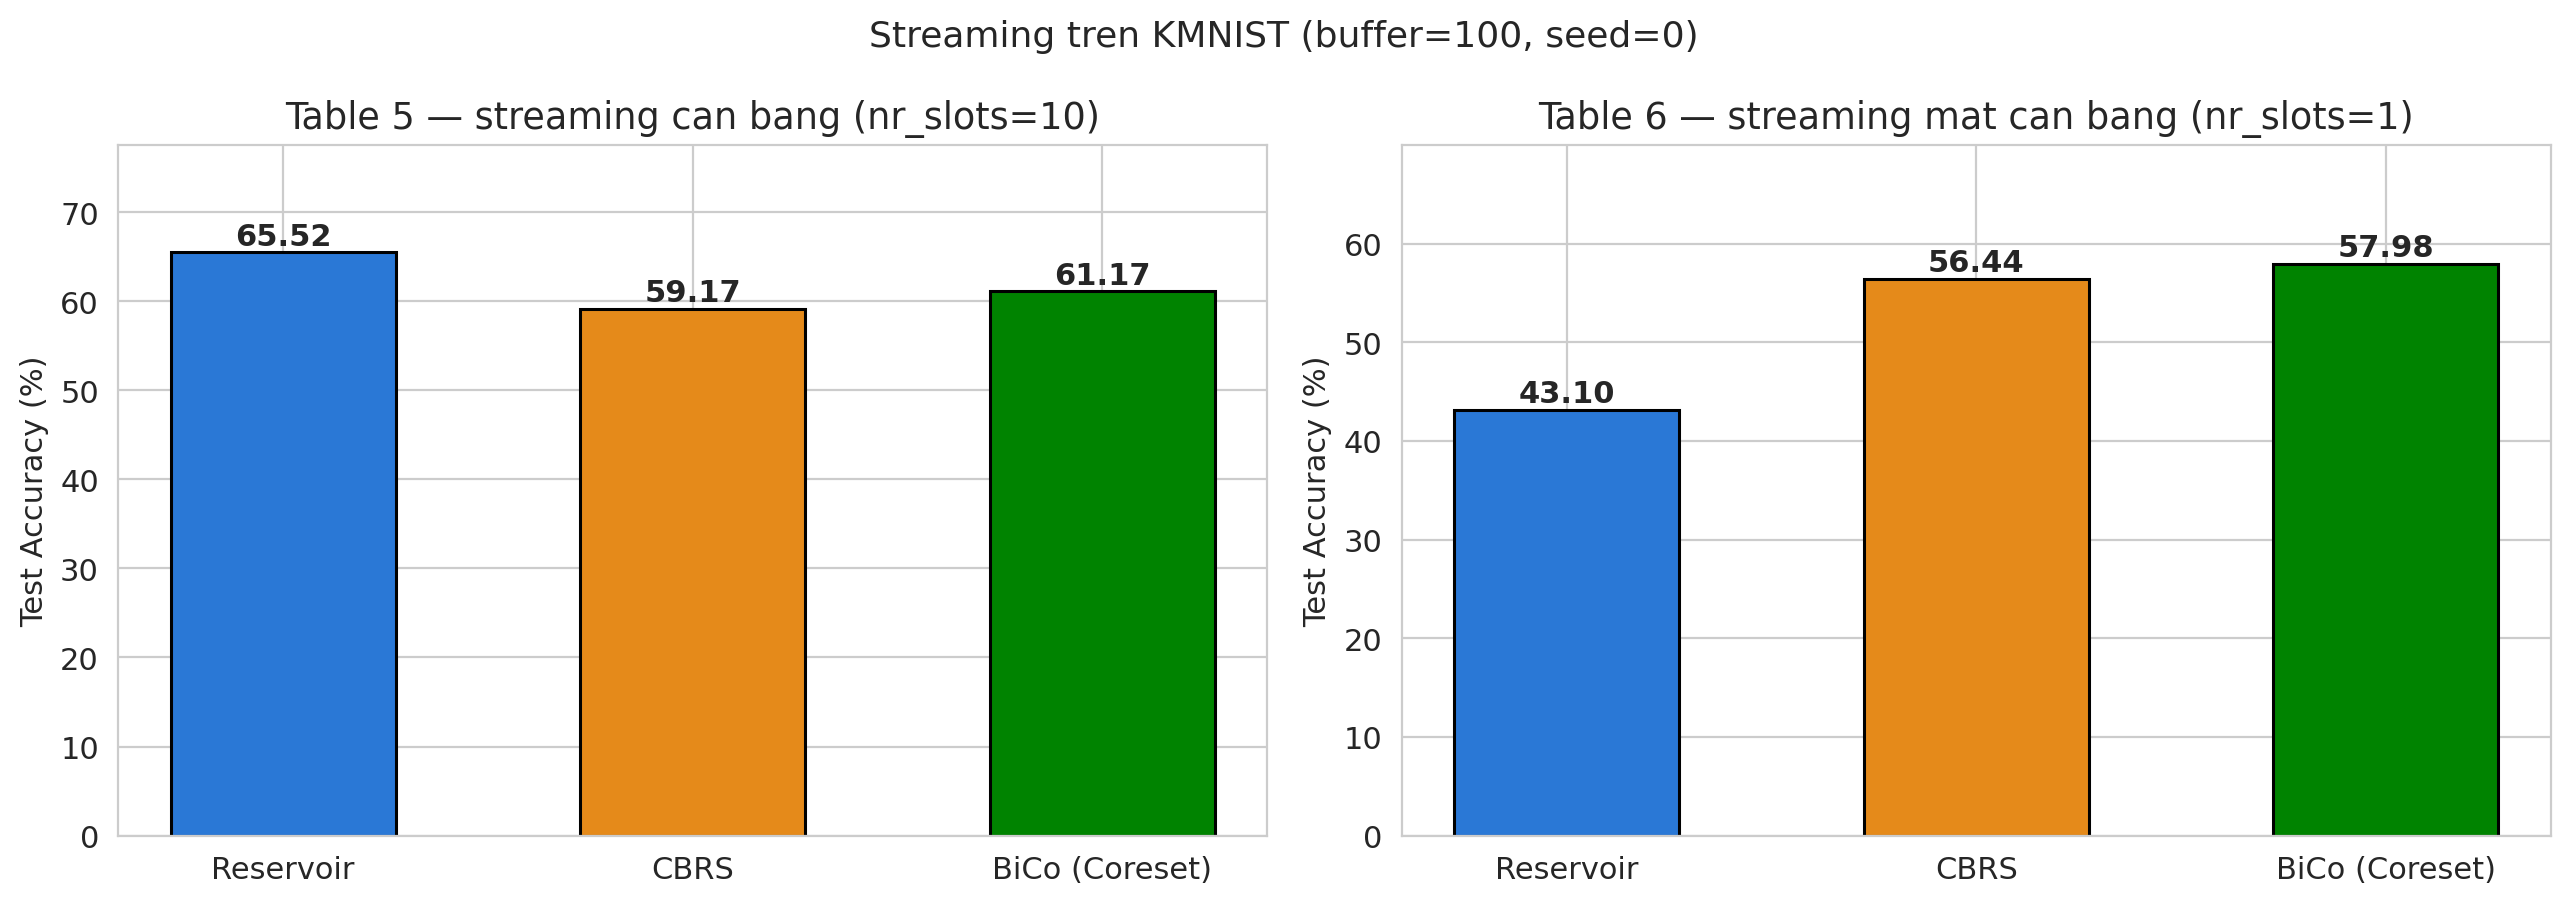

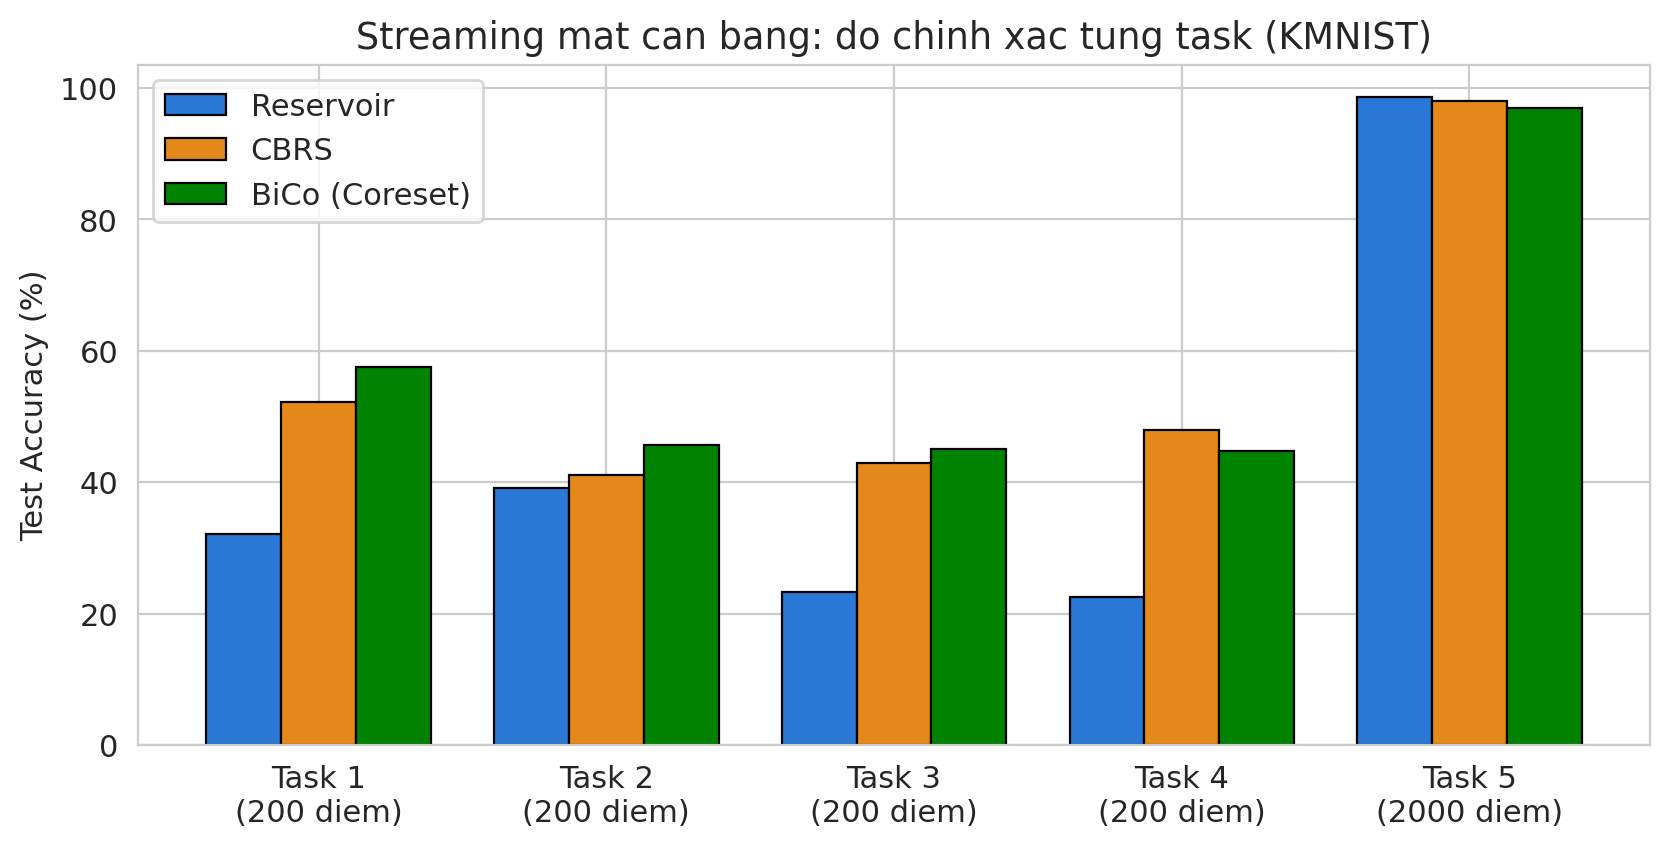

In [15]:
def load_streaming(dataset, method, buffer_size=BUFFER_SIZE, beta=BETA, seed=SEED):
    path = os.path.join(CL_DIR, 'streaming_results',
                        '{}_{}_{}_{}_{}.txt'.format(dataset, method, buffer_size, beta, seed))
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

STREAM_METHODS = ['reservoir', 'cbrs', 'coreset']
LABELS = {'reservoir': 'Reservoir', 'cbrs': 'CBRS', 'coreset': 'BiCo (Coreset)'}
bal = {m: load_streaming(DATASET, m) for m in STREAM_METHODS}
imb = {m: load_streaming(DATASET_IMB, m) for m in STREAM_METHODS}

print('{:<16} {:>18} {:>18}'.format('', 'Table 5 (can bang)', 'Table 6 (mat can bang)'))
print('-' * 54)
for m in STREAM_METHODS:
    b = '{:.2f}'.format(bal[m]['test_acc']) if bal[m] else 'chua chay'
    i = '{:.2f}'.format(imb[m]['test_acc']) if imb[m] else 'chua chay'
    print('{:<16} {:>18} {:>18}'.format(LABELS[m], b, i))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
colors = {'reservoir': '#2a78d6', 'cbrs': '#e58a1a', 'coreset': '#008300'}
for ax, data, title in [(axes[0], bal, 'Table 5 — streaming can bang (nr_slots=10)'),
                        (axes[1], imb, 'Table 6 — streaming mat can bang (nr_slots=1)')]:
    ms = [m for m in STREAM_METHODS if data[m]]
    vals = [data[m]['test_acc'] for m in ms]
    if not ms:
        ax.text(0.5, 0.5, 'chua co ket qua', ha='center', transform=ax.transAxes); continue
    bars = ax.bar([LABELS[m] for m in ms], vals, width=0.55,
                  color=[colors[m] for m in ms], edgecolor='black', linewidth=1.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8, '{:.2f}'.format(v),
                ha='center', fontweight='semibold')
    ax.set_ylabel('Test Accuracy (%)'); ax.set_ylim(0, max(vals) + 12); ax.set_title(title)
fig.suptitle('Streaming tren KMNIST (buffer={}, seed={})'.format(BUFFER_SIZE, SEED), fontsize=13)
plt.tight_layout()
p = os.path.join(FIG_DIR, '09_streaming.png')
plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
show(p)

# Do chinh xac tung task o che do mat can bang: cho thay reservoir bo quen 4 task dau
if all(imb[m] for m in STREAM_METHODS):
    fig, ax = plt.subplots(figsize=(8.5, 4.4))
    width, xs = 0.26, np.arange(5)
    for k, m in enumerate(STREAM_METHODS):
        ax.bar(xs + (k - 1) * width, imb[m]['acc_per_task'], width=width,
               label=LABELS[m], color=colors[m], edgecolor='black', linewidth=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(['Task {}\n(200 diem)'.format(i + 1) for i in range(4)] + ['Task 5\n(2000 diem)'])
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Streaming mat can bang: do chinh xac tung task (KMNIST)')
    ax.legend()
    plt.tight_layout()
    p = os.path.join(FIG_DIR, '10_streaming_per_task.png')
    plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
    show(p, width=780)

---
## Ô 12 — Biến thể của Algorithm 1 (Figure 3, §5.1)

Sáu cách giải bài toán bilevel có ràng buộc lực lượng `‖w‖₀ ≤ m`, xây coreset
**trực tiếp trên ConvNet** (không dùng proxy):

> ⚠️ **Đây KHÔNG phải thiết lập gốc của Sec. 5.1.** Bài báo dùng hồi quy logistic
> trên đặc trưng Nyström của CNTK (2048 chiều), *không* phải CNN huấn luyện trên pixel.
> Phần này là thiết lập khác — khó hơn và tốn kém hơn — nhưng dùng chung *ý tưởng*
> sáu biến thể. Repo mới đã bổ sung script bám sát bài báo; xem **Ô 12b**.

| Tên | Bài báo | Ý tưởng |
|---|---|---|
| `uniform` | mốc so sánh | lấy mẫu ngẫu nhiên |
| `bico_fwd` | Algorithm 1 | chọn tiến từng điểm một |
| `bico_fwd_b` | §3.5.1 | chọn tiến **theo lô** |
| `bico_elim` | §3.5.1 | bắt đầu từ toàn bộ, loại dần |
| `bico_exch` | §3.5.1 | hoán đổi kiểu Fedorov |
| `bico_reg` | Algorithm 2 | coreset **có trọng số** qua phạt `L₁ᐟ²` |

Hai điều bài báo dự đoán, hãy đối chiếu với kết quả:
1. `bico_elim` **thua cả uniform** ở coreset nhỏ (§5.1 — đã tái hiện đúng trên FashionMNIST).
2. `bico_fwd_b` đạt xấp xỉ `bico_fwd` nhưng **rẻ hơn nhiều lần**.

Dừng ở `m = 200`: chi phí xây của `bico_fwd` tăng gần bậc hai theo `m`
(trên FashionMNIST: 50s ở m=50 → **2292s** ở m=800).

`bico_reg` dùng `--reg-outer-it 250 --reg-warm-inner-it 40 --reg-patience 5`
(cao hơn mặc định): trên FashionMNIST đường này rất kém, dấu hiệu là hệ số phạt β
tăng gấp đôi quá nhanh trước khi trọng số kịp hội tụ.

⏱️ Khoảng 45–60 phút.

In [16]:
VAR = [sys.executable, os.path.join(EXP_DIR, 'run_algorithm1_variants_fashion.py'),
       '--dataset', 'kmnist', '--output-dir', ALGO1_DIR]

run(VAR + ['--method', 'full', '--seed', str(SEED)], cwd=REPO, label='variants  full dataset')

for method in VARIANT_METHODS:
    for size in VARIANT_SIZES:
        extra = ['--reg-outer-it', '250', '--reg-warm-inner-it', '40',
                 '--reg-patience', '5'] if method == 'bico_reg' else []
        run(VAR + ['--method', method, '--size', str(size), '--seed', str(SEED)] + extra,
            cwd=REPO, label='variants  {:<12} m={:<4}'.format(method, size))

[ok     362.6s] variants  full dataset  |  full dataset (n=60000): 96.65%  [train 356.5s]
[ok      18.9s] variants  uniform      m=50    |  uniform (m=50, seed=0): 44.44%  [build 0.0s, train 12.4s]
[ok      29.1s] variants  uniform      m=100   |  uniform (m=100, seed=0): 54.15%  [build 0.0s, train 22.6s]
[ok      49.1s] variants  uniform      m=200   |  uniform (m=200, seed=0): 64.63%  [build 0.0s, train 42.7s]
[ok      68.8s] variants  bico_fwd     m=50    |  bico_fwd (m=50, seed=0): 51.82%  [build 50.8s, train 11.5s]
[ok     139.0s] variants  bico_fwd     m=100   |  bico_fwd (m=100, seed=0): 61.75%  [build 111.7s, train 20.8s]
[ok     294.0s] variants  bico_fwd     m=200   |  bico_fwd (m=200, seed=0): 77.35%  [build 245.7s, train 41.7s]
[ok      25.4s] variants  bico_fwd_b   m=50    |  bico_fwd_b (m=50, seed=0): 47.12%  [build 6.8s, train 12.0s]
[ok      41.3s] variants  bico_fwd_b   m=100   |  bico_fwd_b (m=100, seed=0): 56.32%  [build 13.2s, train 21.5s]
[ok      76.6s] variants  

[ok       2.7s] bieu do variants  |  Saved plot to /kaggle/working/bilevel-coresets/kmnist_figures/11_variants_accuracy.png


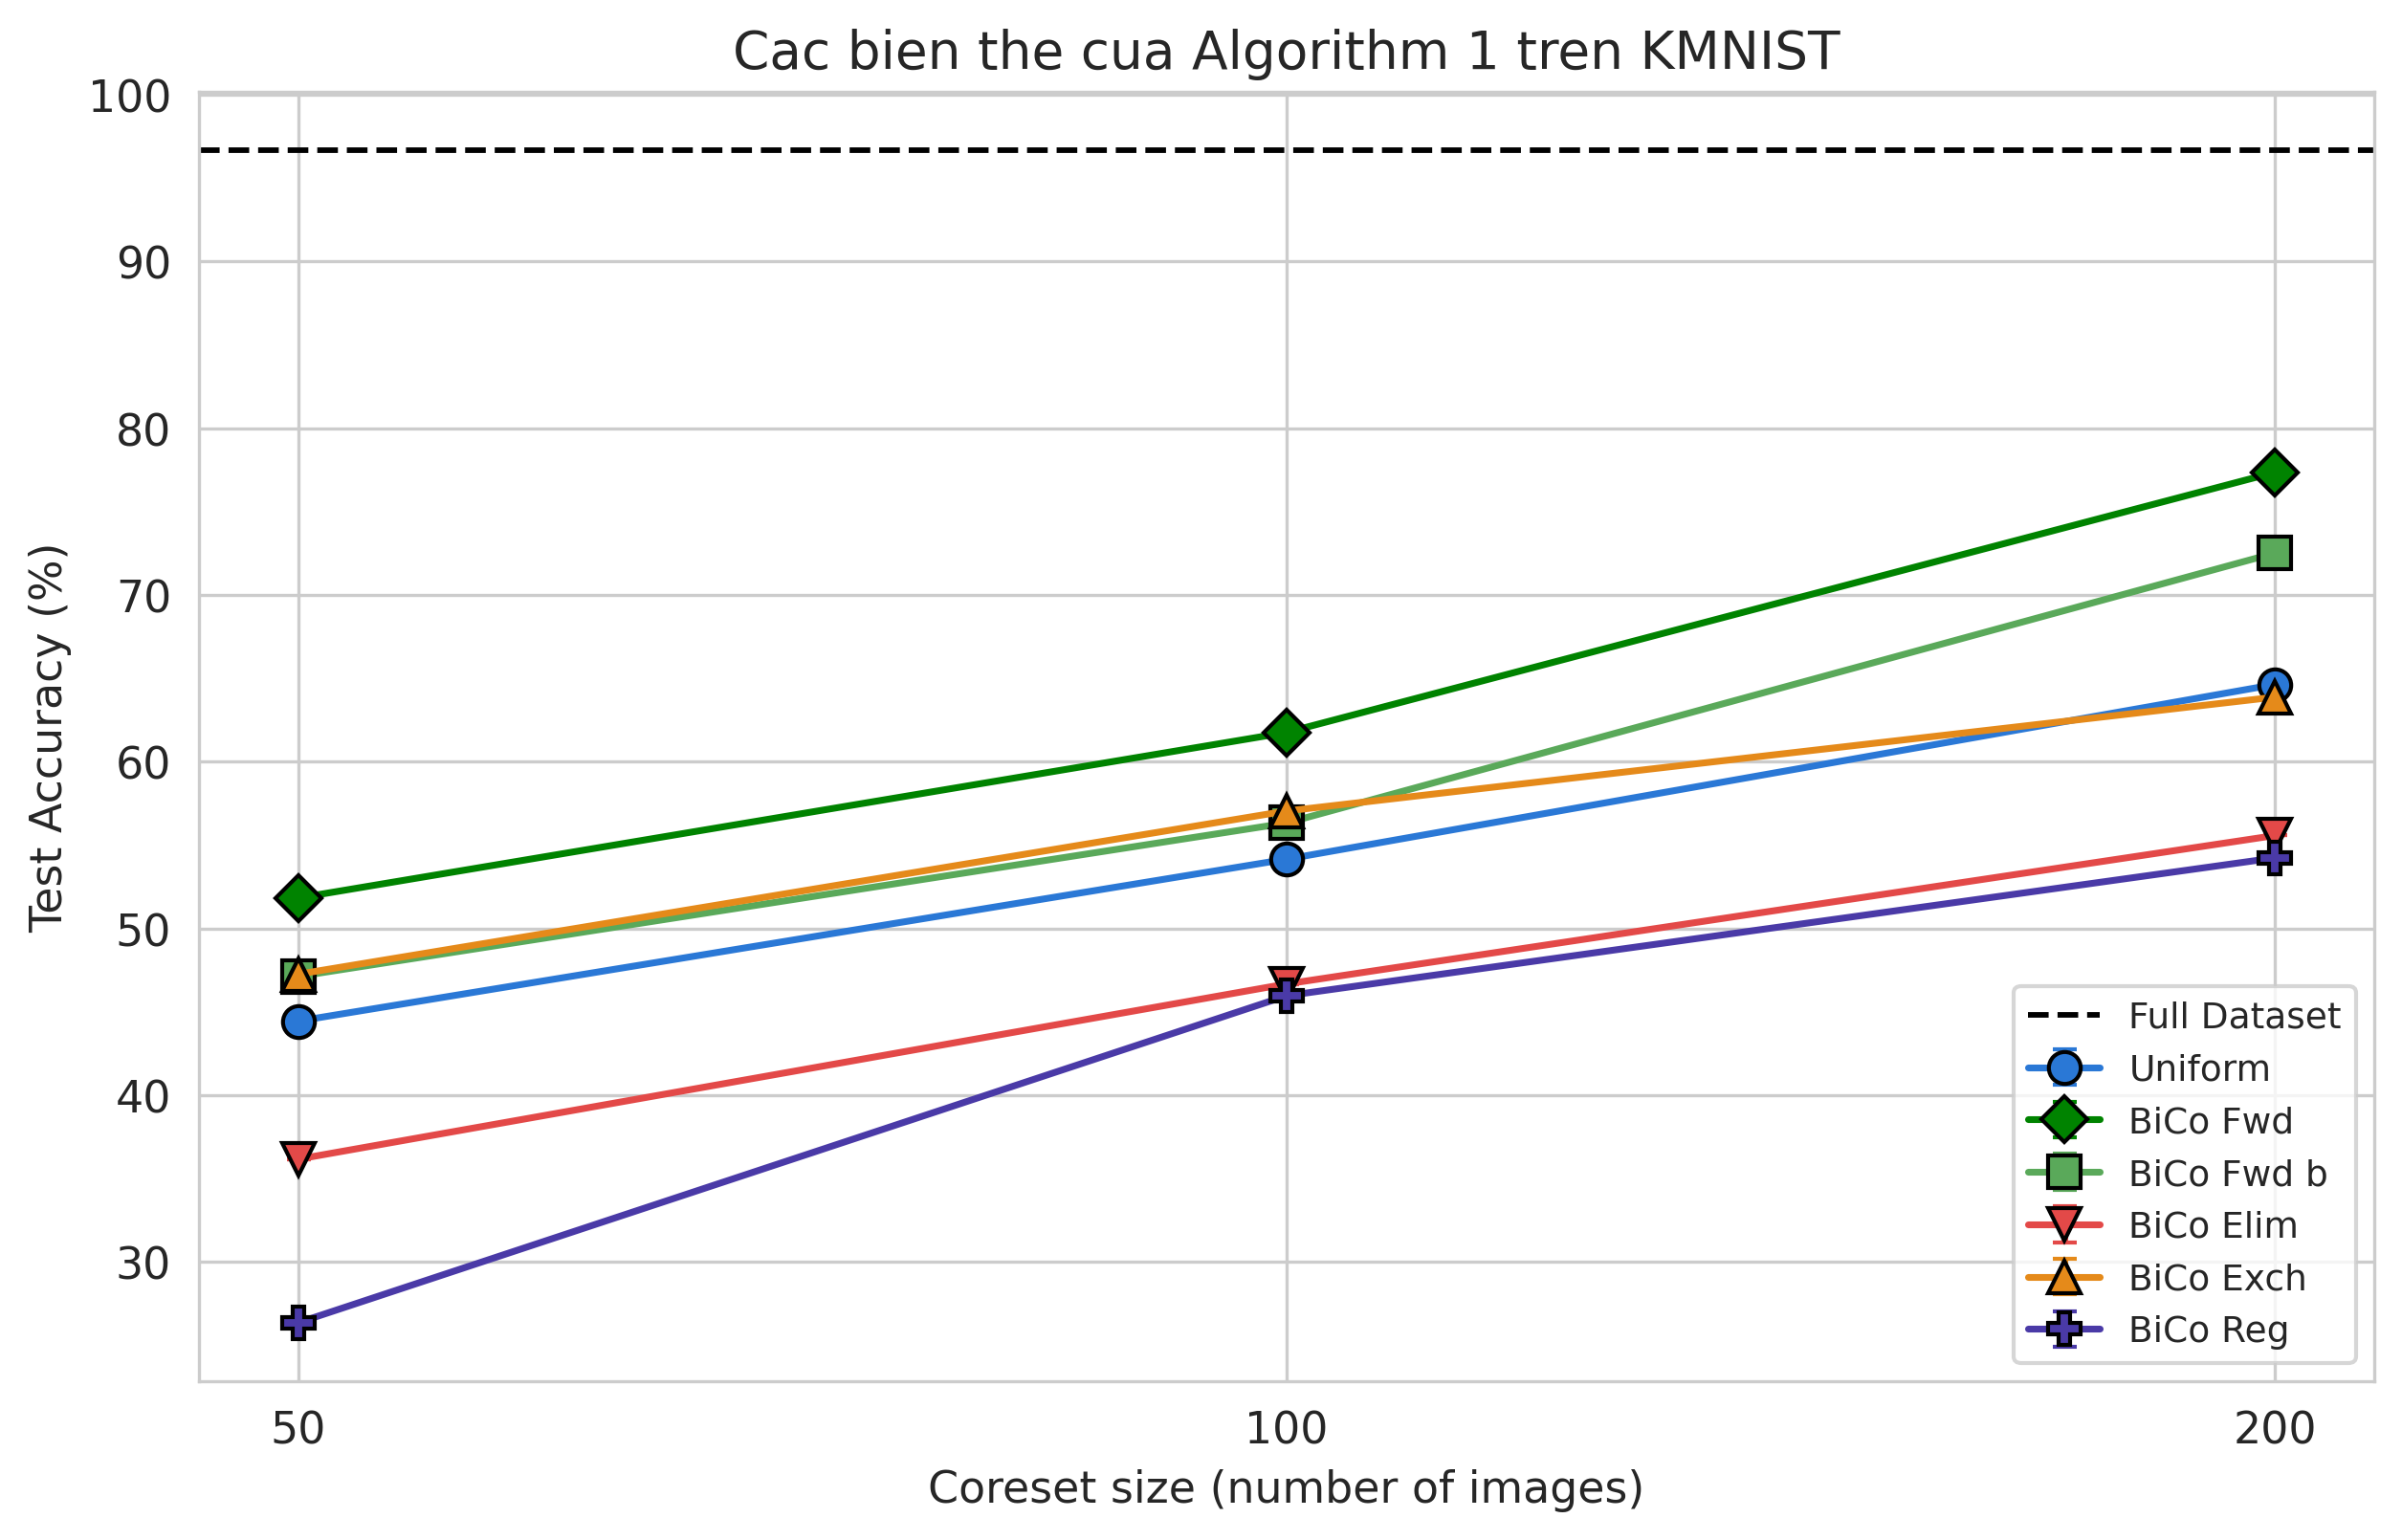

Full dataset (n=60000): 96.65%

phuong phap              m=50            m=100            m=200
---------------------------------------------------------------
uniform           44.44% / 0s      54.15% / 0s      64.63% / 0s
bico_fwd         51.82% / 51s    61.75% / 112s    77.35% / 246s
bico_fwd_b        47.12% / 7s     56.32% / 13s     72.51% / 27s
bico_elim       36.16% / 136s    46.67% / 134s    55.57% / 133s
bico_exch        47.25% / 51s     57.04% / 51s     63.87% / 63s
bico_reg       26.35% / 1267s    45.96% / 145s     54.23% / 27s

(moi o: do chinh xac / thoi gian XAY DUNG coreset)


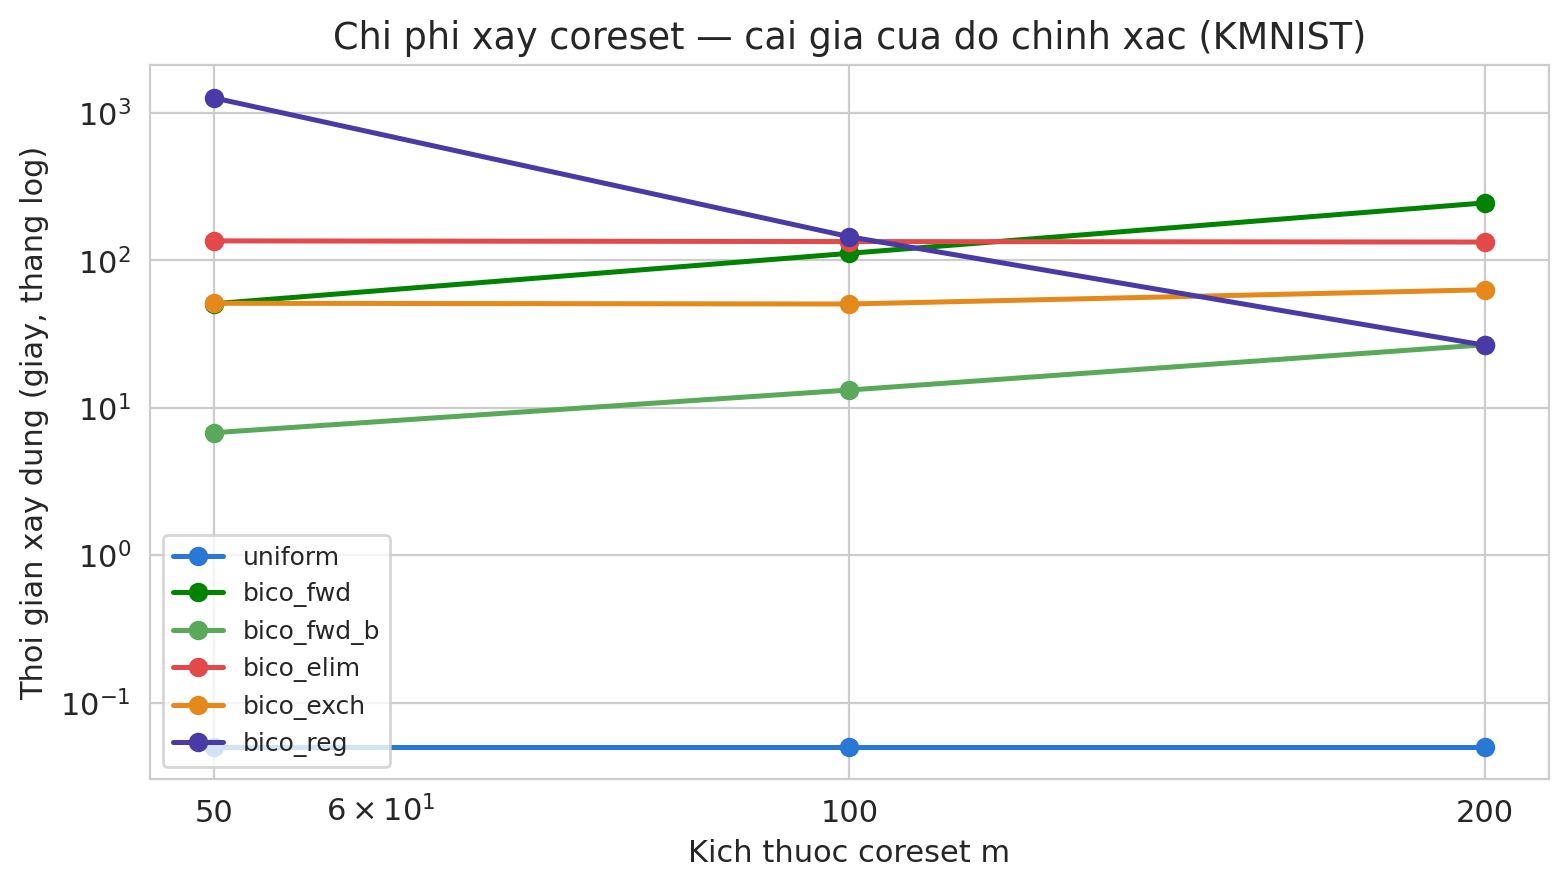

In [17]:
run([sys.executable, os.path.join(EXP_DIR, 'algorithm1_variants_fashion_plot.py'),
     '--sizes', ','.join(str(s) for s in VARIANT_SIZES), '--seeds', str(SEED),
     '--results-dir', ALGO1_DIR,
     '--output', os.path.join(FIG_DIR, '11_variants_accuracy.png'),
     '--title', 'Cac bien the cua Algorithm 1 tren KMNIST'],
    cwd=REPO, label='bieu do variants')
show(os.path.join(FIG_DIR, '11_variants_accuracy.png'))

# Bang so + bieu do chi phi xay dung (build time) -- diem manh that su cua fwd_b
def load_variant(method, size, seed=SEED):
    path = os.path.join(ALGO1_DIR, '{}_{}_{}.txt'.format(method, size, seed))
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

full_path = os.path.join(ALGO1_DIR, 'full_{}.txt'.format(SEED))
full_acc = json.load(open(full_path))['test_acc'] if os.path.exists(full_path) else None
if full_acc:
    print('Full dataset (n=60000): {:.2f}%\n'.format(full_acc))

hdr = '{:<12}' + ' {:>16}' * len(VARIANT_SIZES)
print(hdr.format('phuong phap', *['m={}'.format(s) for s in VARIANT_SIZES]))
print('-' * (12 + 17 * len(VARIANT_SIZES)))
for method in VARIANT_METHODS:
    cells = []
    for s in VARIANT_SIZES:
        d = load_variant(method, s)
        cells.append('{:.2f}% / {:.0f}s'.format(d['test_acc'], d['build_time']) if d else '--')
    print(hdr.format(method, *cells))
print('\n(moi o: do chinh xac / thoi gian XAY DUNG coreset)')

fig, ax = plt.subplots(figsize=(8, 4.6))
COLORS_V = {'uniform': '#2a78d6', 'bico_fwd': '#008300', 'bico_fwd_b': '#5aa95a',
            'bico_elim': '#e34948', 'bico_exch': '#e58a1a', 'bico_reg': '#4a3aa7'}
for method in VARIANT_METHODS:
    xs, ys = [], []
    for s in VARIANT_SIZES:
        d = load_variant(method, s)
        if d:
            xs.append(s); ys.append(max(d['build_time'], 0.05))
    if xs:
        ax.plot(xs, ys, marker='o', label=method, color=COLORS_V[method], linewidth=1.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks(VARIANT_SIZES); ax.set_xticklabels([str(s) for s in VARIANT_SIZES])
ax.set_xlabel('Kich thuoc coreset m'); ax.set_ylabel('Thoi gian xay dung (giay, thang log)')
ax.set_title('Chi phi xay coreset — cai gia cua do chinh xac (KMNIST)')
ax.legend(fontsize=9)
plt.tight_layout()
p = os.path.join(FIG_DIR, '12_variants_buildtime.png')
plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
show(p, width=760)

---
## Ô 12b *(tuỳ chọn)* — Sec. 5.1 đúng chuẩn bài báo: proxy CNTK-Nyström

Repo vừa bổ sung `run_algorithm1_variants_paper_cifar10.py` — bản tái hiện **sát bài báo**
của Figure 3, khác Ô 12 ở chỗ:

| | Ô 12 (`..._fashion.py`) | Ô 12b (`..._paper_cifar10.py`) |
|---|---|---|
| Mô hình đích | ConvNet trên pixel | **hồi quy logistic trên đặc trưng Nyström của CNTK (q=2048)** |
| Đúng Sec. 5.1? | không — thiết lập khác | **có** (với `--dataset cifar10`) |
| Kích thước coreset | số ảnh tuyệt đối | **% của tập train** (trục x của Figure 3) |
| Tên biến thể chọn theo lô | `bico_fwd_b` | `bico_fwd25` (đúng b=25 của bài báo) |
| IHVP | chuỗi Neumann | **100 bước conjugate-gradient** (giá trị bài báo) |
| Warm-start | đối xứng | **5e4 bước đầu, rồi 1e4 mỗi bước** (Appendix C) |

Ô 4 đã thêm lựa chọn `--dataset kmnist` vào script này.

> 🕐 **Vì sao mặc định TẮT.** Chính docstring của script cảnh báo: tính ánh xạ đặc trưng
> CNTK-Nyström (2048 landmark × 54.000 ảnh, kernel 6 tầng) **rất tốn thời gian kể cả
> trên GPU Kaggle**. Ô này chạy ở **cấu hình smoke-test** (`--nystrom-dim 128`,
> `--train-pool-size 2000`) đúng như docstring gợi ý — đủ để chứng minh pipeline
> chạy được trên KMNIST, **không phải** số liệu dùng để báo cáo.
>
> Muốn số liệu thật: đặt `RUN_PAPER_S51 = True` ở Ô 3, **bỏ hết các cờ override**
> trong `SMOKE` bên dưới, và dành riêng một phiên Kaggle cho nó. Đặc trưng được
> cache lại (`--features-cache-dir`) nên chỉ phải tính một lần cho mọi method/size.
>
> 📌 Kết quả KMNIST từ script này **không phải số của bài báo** — nó là "phương pháp
> luận Sec. 5.1, áp lên bộ dữ liệu khác". Báo cáo riêng, đừng trộn với Figure 3.

In [18]:
PAPER_DIR   = os.path.join(EXP_DIR, 'algo1_paper_kmnist_results')
CACHE_DIR   = os.path.join(EXP_DIR, 'cntk_features_cache')
PAPER_SIZES = [0.5, 2, 8]          # % cua tap train (truc x cua Figure 3)

# Cau hinh smoke-test theo goi y trong docstring cua script.
# XOA danh sach nay de chay dung gia tri bai bao (rat lau!).
SMOKE = ['--nystrom-dim', '128', '--train-pool-size', '2000', '--val-size', '200',
         '--first-inner-it', '200', '--max-inner-it', '50']

if not RUN_PAPER_S51:
    print('Bo qua O 12b (RUN_PAPER_S51 = False).')
    print('Dat RUN_PAPER_S51 = True o O 3 neu muon chay.')
else:
    PAPER = [sys.executable, os.path.join(EXP_DIR, 'run_algorithm1_variants_paper_cifar10.py'),
             '--dataset', 'kmnist', '--output-dir', PAPER_DIR,
             '--features-cache-dir', CACHE_DIR]
    run(PAPER + ['--method', 'full', '--seed', str(SEED)] + SMOKE,
        cwd=REPO, label='paper-S5.1  full')
    for method in ['uniform', 'bico_fwd', 'bico_fwd25', 'bico_elim', 'bico_exch', 'bico_reg']:
        for pct in PAPER_SIZES:
            run(PAPER + ['--method', method, '--size-pct', str(pct), '--seed', str(SEED)] + SMOKE,
                cwd=REPO, label='paper-S5.1  {:<11} {}%'.format(method, pct))

    run([sys.executable, os.path.join(EXP_DIR, 'algorithm1_variants_paper_cifar10_plot.py'),
         '--dataset', 'kmnist', '--seeds', str(SEED),
         '--sizes-pct', ','.join(str(x) for x in PAPER_SIZES)],
        cwd=REPO, label='paper-S5.1  bieu do')
    src = os.path.join(EXP_DIR, 'algorithm1_variants_paper_kmnist_accuracy.png')
    if os.path.exists(src):
        shutil.copy(src, os.path.join(FIG_DIR, '14_paper_s51_kmnist.png'))
        show(os.path.join(FIG_DIR, '14_paper_s51_kmnist.png'))

Bo qua O 12b (RUN_PAPER_S51 = False).
Dat RUN_PAPER_S51 = True o O 3 neu muon chay.


---
## Ô 13 — Đối chiếu KMNIST với FashionMNIST

Câu hỏi cốt lõi của toàn bộ thực nghiệm này: **kết luận rút ra trên FashionMNIST có
lặp lại trên một miền dữ liệu khác không?**

Số FashionMNIST dưới đây lấy từ notebook `fashion-data-experiment.ipynb` (seed 0,
cùng siêu tham số). Chúng được ghi cứng vì repo được clone mới nên trên đĩa không có
file kết quả FashionMNIST — mọi con số KMNIST trong biểu đồ đều đọc từ file thật.

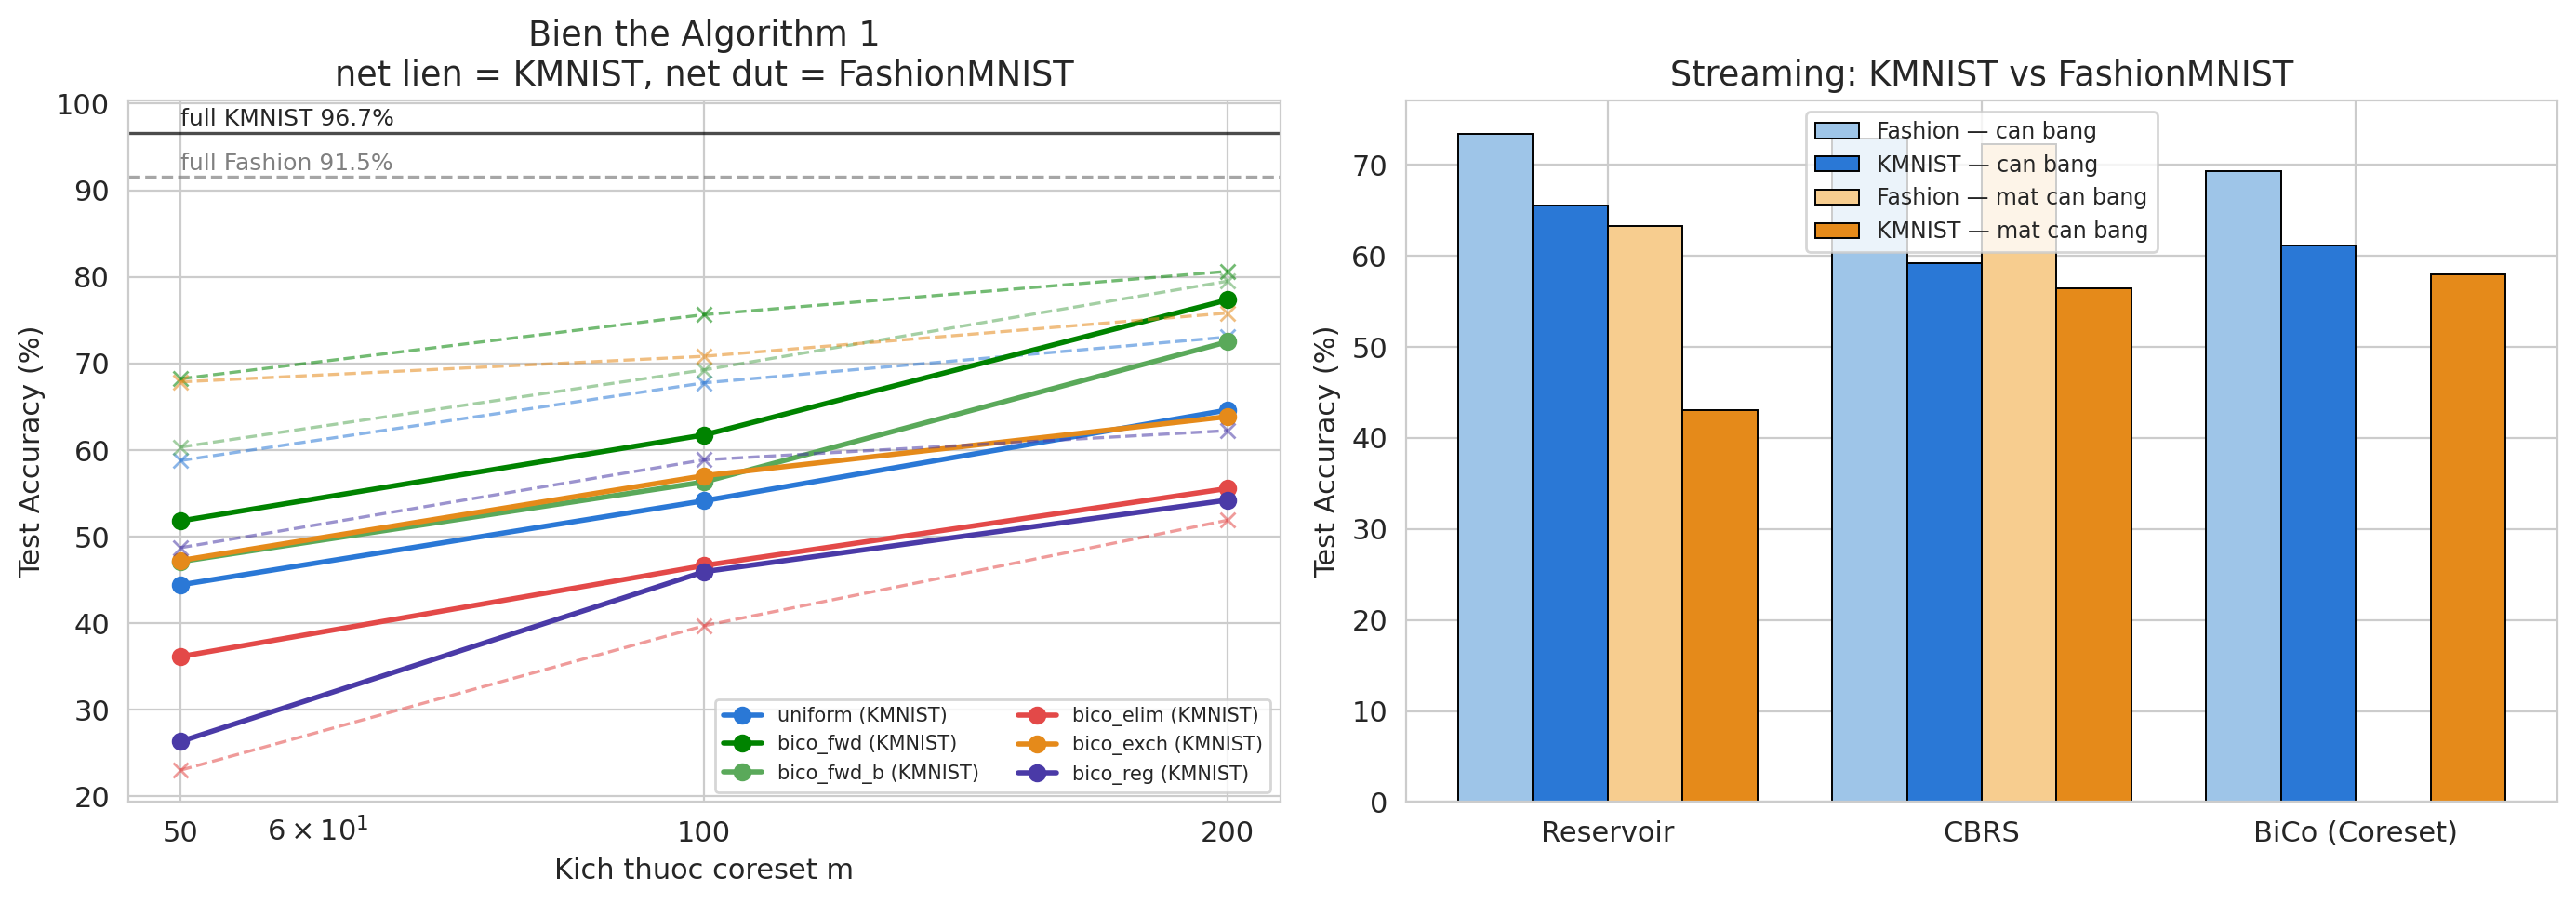

Kiem tra 2 du doan cua bai bao tren KMNIST:
  1) bico_elim thua uniform o 3/3 kich thuoc  -> DUNG nhu Sec. 5.1
  2) tai m=200: fwd 77.35% (246s xay) vs fwd_b 72.51% (27s xay) -> fwd_b re hon 9.2 lan


In [19]:
# --- so lieu FashionMNIST, seed 0, tu notebook fashion-data-experiment.ipynb ---
FASHION = {
    'streaming_balanced':   {'reservoir': 73.37, 'cbrs': 72.88, 'coreset': 69.28},
    'streaming_imbalanced': {'reservoir': 63.30, 'cbrs': 72.26},   # coreset: chua chay
    'variants': {   # {method: {size: (acc, build_time)}}
        'uniform':    {50: (58.79, 0.0),   100: (67.76, 0.0),   200: (73.06, 0.0)},
        'bico_fwd':   {50: (68.23, 50.2),  100: (75.64, 113.0), 200: (80.64, 251.0)},
        'bico_fwd_b': {50: (60.35, 6.7),   100: (69.26, 13.0),  200: (79.51, 26.5)},
        'bico_elim':  {50: (23.04, 135.2), 100: (39.72, 137.3), 200: (51.91, 135.8)},
        'bico_exch':  {50: (67.87, 52.4),  100: (70.83, 53.0),  200: (75.83, 64.7)},
        'bico_reg':   {50: (48.73, 618.8), 100: (58.88, 41.5),  200: (62.25, 33.6)},
    },
    'full': 91.55,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) duong cong bien the: KMNIST (net lien) vs FashionMNIST (net dut)
ax = axes[0]
for method in VARIANT_METHODS:
    xs_k = [s for s in VARIANT_SIZES if load_variant(method, s)]
    if xs_k:
        ax.plot(xs_k, [load_variant(method, s)['test_acc'] for s in xs_k],
                marker='o', color=COLORS_V[method], linewidth=2, label='{} (KMNIST)'.format(method))
    xs_f = [s for s in VARIANT_SIZES if s in FASHION['variants'][method]]
    ax.plot(xs_f, [FASHION['variants'][method][s][0] for s in xs_f],
            marker='x', color=COLORS_V[method], linewidth=1.2, linestyle='--', alpha=0.55)
if full_acc:
    ax.axhline(full_acc, color='black', linestyle='-', linewidth=1.2, alpha=0.7)
    ax.text(VARIANT_SIZES[0], full_acc + 0.8, 'full KMNIST {:.1f}%'.format(full_acc), fontsize=9)
ax.axhline(FASHION['full'], color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(VARIANT_SIZES[0], FASHION['full'] + 0.8, 'full Fashion {:.1f}%'.format(FASHION['full']),
        fontsize=9, color='gray')
ax.set_xscale('log'); ax.set_xticks(VARIANT_SIZES)
ax.set_xticklabels([str(s) for s in VARIANT_SIZES])
ax.set_xlabel('Kich thuoc coreset m'); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Bien the Algorithm 1\nnet lien = KMNIST, net dut = FashionMNIST')
ax.legend(fontsize=7.5, ncol=2, loc='lower right')

# (b) streaming: 2 bo du lieu canh nhau
ax = axes[1]
xs = np.arange(3); width = 0.2
k_bal = [bal[m]['test_acc'] if bal[m] else np.nan for m in STREAM_METHODS]
k_imb = [imb[m]['test_acc'] if imb[m] else np.nan for m in STREAM_METHODS]
f_bal = [FASHION['streaming_balanced'].get(m, np.nan) for m in STREAM_METHODS]
f_imb = [FASHION['streaming_imbalanced'].get(m, np.nan) for m in STREAM_METHODS]
for k, (vals, lab, col) in enumerate([
        (f_bal, 'Fashion — can bang', '#9ec5e8'), (k_bal, 'KMNIST — can bang', '#2a78d6'),
        (f_imb, 'Fashion — mat can bang', '#f7cd8f'), (k_imb, 'KMNIST — mat can bang', '#e58a1a')]):
    ax.bar(xs + (k - 1.5) * width, vals, width=width, label=lab,
           color=col, edgecolor='black', linewidth=0.7)
ax.set_xticks(xs); ax.set_xticklabels([LABELS[m] for m in STREAM_METHODS])
ax.set_ylabel('Test Accuracy (%)'); ax.set_title('Streaming: KMNIST vs FashionMNIST')
ax.legend(fontsize=8.5)
plt.tight_layout()
p = os.path.join(FIG_DIR, '13_kmnist_vs_fashion.png')
plt.savefig(p, dpi=200, bbox_inches='tight'); plt.close()
show(p)

print('Kiem tra 2 du doan cua bai bao tren KMNIST:')
d_el = [load_variant('bico_elim', s) for s in VARIANT_SIZES]
d_un = [load_variant('uniform', s) for s in VARIANT_SIZES]
if all(d_el) and all(d_un):
    worse = sum(e['test_acc'] < u['test_acc'] for e, u in zip(d_el, d_un))
    print('  1) bico_elim thua uniform o {}/{} kich thuoc  -> {}'.format(
        worse, len(VARIANT_SIZES), 'DUNG nhu Sec. 5.1' if worse >= 2 else 'KHONG lap lai'))
d_f, d_fb = load_variant('bico_fwd', VARIANT_SIZES[-1]), load_variant('bico_fwd_b', VARIANT_SIZES[-1])
if d_f and d_fb:
    print('  2) tai m={}: fwd {:.2f}% ({:.0f}s xay) vs fwd_b {:.2f}% ({:.0f}s xay) '
          '-> fwd_b re hon {:.1f} lan'.format(
              VARIANT_SIZES[-1], d_f['test_acc'], d_f['build_time'],
              d_fb['test_acc'], d_fb['build_time'],
              d_f['build_time'] / max(d_fb['build_time'], 0.01)))

---
## Ô 14 — Đóng gói kết quả

Gom mọi hình và mọi file JSON kết quả vào `kmnist_experiment_output/` rồi nén lại
để tải về / đưa vào báo cáo.

In [20]:
OUT = os.path.join(REPO, 'kmnist_experiment_output')
shutil.rmtree(OUT, ignore_errors=True)
os.makedirs(OUT, exist_ok=True)
shutil.copytree(FIG_DIR, os.path.join(OUT, 'figures'))

for sub, src_dir, pattern in [
    ('cl_results',        os.path.join(CL_DIR, 'cl_results'),        'splitkmnist'),
    ('streaming_results', os.path.join(CL_DIR, 'streaming_results'), 'splitkmnist'),
    ('algo1_results',     ALGO1_DIR,                                 ''),
]:
    dst = os.path.join(OUT, sub)
    os.makedirs(dst, exist_ok=True)
    if os.path.isdir(src_dir):
        for fn in sorted(os.listdir(src_dir)):
            if fn.startswith(pattern) and fn.endswith('.txt'):
                shutil.copy(os.path.join(src_dir, fn), os.path.join(dst, fn))
    print('{:<20} {} file'.format(sub, len(os.listdir(dst))))

archive = shutil.make_archive(os.path.join(REPO, 'kmnist_experiment_output'), 'zip', OUT)
print('\nDa nen: {} ({:.1f} MB)'.format(archive, os.path.getsize(archive) / 1e6))

print('\nHinh da tao:')
for fn in sorted(os.listdir(FIG_DIR)):
    print('  ' + fn)

if FAILURES:
    print('\n!! {} lenh that bai (ket qua tuong ung bi thieu trong bieu do):'.format(len(FAILURES)))
    for f in FAILURES:
        print('   - ' + f)
else:
    print('\nTat ca cac lenh chay thanh cong.')

cl_results           26 file
streaming_results    6 file
algo1_results        19 file

Da nen: /kaggle/working/bilevel-coresets/kmnist_experiment_output.zip (2.5 MB)

Hinh da tao:
  01_kmnist_samples.png
  02_kmnist_normalization.png
  03_cl_accuracy.png
  04_cl_forgetting.png
  05_cl_tradeoff.png
  06_ablation.png
  07_gap_vs_buffer.png
  08_multiseed.png
  09_streaming.png
  10_streaming_per_task.png
  11_variants_accuracy.png
  12_variants_buildtime.png
  13_kmnist_vs_fashion.png

Tat ca cac lenh chay thanh cong.


---
## Kết luận — điền sau khi chạy xong

Ba câu hỏi cần trả lời bằng số liệu ở trên:

1. **BiCo có nhất quán hơn uniform trên KMNIST không?**
   Đây là luận điểm chính của Table 3 — bài báo nhấn mạnh BiCo là phương pháp *duy nhất*
   vượt uniform trên **cả ba** bộ dữ liệu. Xem Ô 7 (bảng), Ô 8 (biểu đồ) và
   **Ô 10** (error bar — nếu chênh lệch nhỏ hơn 2× độ lệch giữa các seed thì
   *không được* khẳng định là thắng).

2. **Lợi thế có tăng lên khi buffer nhỏ lại không?** (Ô 9)
   Bài báo, Table 9: trên SMNIST chênh lệch là +6,4 ở `m=50` nhưng chỉ +1,9 ở `m=200`.

3. **Các kết luận về biến thể có lặp lại trên miền dữ liệu khác không?** (Ô 12, Ô 13)
   Cụ thể: `bico_elim` thua uniform ở coreset nhỏ, và `bico_fwd_b` đạt xấp xỉ `bico_fwd`
   với chi phí xây dựng thấp hơn hẳn.

### Những giới hạn cần ghi rõ trong báo cáo

- 13 trong 15 phương pháp continual learning chỉ chạy **một seed**; chỉ `uniform` và
  `coreset` có 3 seed. Đừng diễn giải chênh lệch dưới ~1 điểm giữa các baseline một seed.
- Coreset trong `cl.py` dùng **proxy NTK** (§3.5.2), không phải Algorithm 1 chạy trực tiếp
  trên ConvNet — đúng như bài báo làm cho Table 3 (để công bằng về thời gian xây dựng).
- Bài báo tự nêu ở §6.1: **chi phí xây coreset cao hơn chi phí huấn luyện trên toàn bộ
  dữ liệu**. Phương pháp này dành cho ràng buộc bộ nhớ / công sức gán nhãn, *không phải*
  để tăng tốc huấn luyện. Biểu đồ chi phí xây dựng ở Ô 12 minh họa trực tiếp điều này.
- `VARIANT_SIZES` dừng ở 200 vì lý do thời gian, nên chưa chạm tới vùng coreset lớn
  (bài báo Figure 3 quét tới 100% dữ liệu).

### Nguồn

- Borsos, Mutný, Tagliasacchi, Krause. *Data Summarization via Bilevel Optimization.*
  JMLR 25 (2024) 1–53. [arXiv:2109.12534](https://arxiv.org/abs/2109.12534)
- Clanuwat và cộng sự. *Deep Learning for Classical Japanese Literature*, 2018 (KMNIST).
  [arXiv:1812.01718](https://arxiv.org/abs/1812.01718)
- Mã nguồn gốc: [zalanborsos/bilevel_coresets](https://github.com/zalanborsos/bilevel_coresets)